# Retrieval-Augmented Generation for Aviation Manuals

Large Language Models (LLMs) are powerful tools for generating natural language responses, but their knowledge is limited to the data used during training and may not include domain-specific or up-to-date information. In addition, LLMs may generate incorrect or unsupported statements when asked about specialized topics. Retrieval-Augmented Generation (RAG) addresses this limitation by combining language models with an external knowledge retrieval system.

In a RAG pipeline, relevant information is first retrieved from a document corpus using embedding-based similarity search. The retrieved passages are then provided to a language model together with the user query, enabling the model to generate responses grounded in the retrieved documents. This approach improves factual accuracy, allows the use of domain-specific knowledge, and enables traceability by referencing the original sources.

The project focuses on building the main components of a RAG pipeline, including document ingestion, text chunking, embedding generation, retrieval, and answer generation. In addition, different design choices for the RAG system—such as chunking strategies, embedding models, and retrieval configurations—are evaluated to assess their impact on the quality and groundedness of generated answers.


In [3]:
import json
import math
import os
import queue
import re
import threading
import time
import warnings
from typing import List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tiktoken
from IPython.display import Markdown, display
from tqdm import tqdm
from dotenv import load_dotenv
from langchain.chains import create_retrieval_chain
from langchain.chains.combine_documents import create_stuff_documents_chain
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.cross_encoders import HuggingFaceCrossEncoder
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain.retrievers import ContextualCompressionRetriever
from langchain.retrievers.document_compressors import CrossEncoderReranker
from langchain_text_splitters import RecursiveCharacterTextSplitter
from unstructured.chunking.title import chunk_by_title
from unstructured.documents.elements import NarrativeText, Title

os.environ.setdefault("MPLCONFIGDIR", os.path.join(os.getcwd(), ".matplotlib"))

# Avoid a known FAISS/OpenMP issue on Apple Silicon.
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

load_dotenv()

DATA_DIR = "data"
TASK_DIR = "task"
FAISS_INDEX_DIR = os.path.join(DATA_DIR, "faiss_index")
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(TASK_DIR, exist_ok=True)



## Data Description

For this project we did not use the dataset suggested in the mini-challenge description (the cleantech media corpus). The original challenge proposes a corpus of approximately 10,000 cleantech-related media articles intended for experimentation with Retrieval-Augmented Generation (RAG) systems.

Instead, our RAG system is built on **four operational aviation manuals used by Edelweiss Air pilots and cabin crew for the Airbus A340**. These documents contain domain-specific operational knowledge used in real airline operations.

**1. Flight Crew Techniques Manual (FCTM)**  
Provides detailed explanations of aircraft handling techniques, cockpit procedures, and operational best practices for Airbus A340 pilots. It includes guidance on topics such as task sharing in the cockpit, aircraft systems usage, and recommended techniques during different phases of flight.

**2. Operations Manual Part A (OM-A)**  
Describes the organisational structure, operational policies, and responsibilities within Edelweiss Air flight operations. It includes regulations, duties of crew members, operational control procedures, and compliance with aviation authorities.

**3. Quick Reference Handbook (QRH)**  
A condensed operational handbook used by pilots during flight. It contains checklists and procedures for normal, abnormal, and emergency situations and is designed for quick access to critical procedures.

**4. Cabin Safety Procedures Manual (CSPM)**  
Contains procedures for cabin crew operations and passenger safety, including safety briefings, emergency procedures, and passenger management during different phases of flight.


#### Differences from the Original RAG Challenge Dataset

The aviation manuals differ significantly from the dataset proposed in the mini-challenge:

| Aspect | Cleantech Dataset | Aviation Manuals |
|------|------------------|------------------|
| **Domain** | General news articles about clean technology | Highly specialized aviation operations knowledge |
| **Structure** | Mostly unstructured narrative text | Strong hierarchical structure with procedures and checklists |
| **Information Type** | Descriptive and explanatory | Procedural, safety-critical instructions |
| **Corpus Size** | ~10,000 articles | Few but very large technical manuals (hundreds of pages each) |
| **Retrieval Challenge** | Topic-based retrieval | Precise retrieval of operational procedures |

Because of these differences, our RAG system must retrieve **very precise passages from highly structured technical documents**, which poses different challenges compared to retrieving information from general news articles.


In [4]:
MANUAL_NAME_MAP = {
    "EDW FCTM A340.pdf": "FCTM",
    "EDW OM A.pdf": "OM A",
    "EDW QRH A340.pdf": "QRH",
    "EDW CSPM.pdf": "CSPM",
}

SECTION_PREFIX_MAP = {
    "FCTM": "FCTM",
    "OM A": "OMA",
    "QRH": "QRH",
    "CSPM": "CSPM",
}

NUMBERED_SECTION_PATTERN = re.compile(r"(?<!\d)(\d+(?:\.\d+)+)\s+\S")
QRH_SECTION_PATTERN = re.compile(r"^((?:[A-Z]+(?:-[A-Z]+)*)?)-(\d+(?:\.\d+)?[A-Z]?)\s+\S")
QRH_CHAPTER_PATTERN = re.compile(r"^(ABN(?:-[A-Z]+)*|MEL|SUPP|INFO)\s*$")
PAGE_ID_PATTERN = re.compile(r"^(\d+(?:\.\d+)?[A-Z]?)$")
TOC_LINE_PATTERN = re.compile(r"\.{2,}\s*\d+\s*$")


def is_toc_line(line: str) -> bool:
    """Return True when a line looks like a table-of-contents entry."""
    return bool(TOC_LINE_PATTERN.search(line.strip()))


def is_probable_toc_page(page_text: str) -> bool:
    """Heuristically detect table-of-contents pages."""
    lines = [line.strip() for line in page_text.splitlines() if line.strip()]
    if not lines:
        return False

    toc_lines = sum(1 for line in lines if is_toc_line(line))
    return toc_lines >= 2 and toc_lines / len(lines) >= 0.2


def infer_section(
    page_text: str,
    manual_name: str,
    current_section: str | None,
) -> str | None:
    """Infer a section label from a manual page."""
    if manual_name in {"OM A", "CSPM"}:
        prefix = SECTION_PREFIX_MAP[manual_name]
        for raw_line in page_text.splitlines():
            line = raw_line.strip()
            if not line or is_toc_line(line):
                continue

            match = NUMBERED_SECTION_PATTERN.search(line)
            if match:
                return f"{prefix}-{match.group(1)}"
        return current_section

    if manual_name == "QRH":
        prefix = (
            current_section.rsplit("-", 1)[0]
            if current_section and "-" in current_section
            else SECTION_PREFIX_MAP["QRH"]
        )
        for raw_line in page_text.splitlines():
            line = raw_line.strip()
            if not line:
                continue

            chapter_match = QRH_CHAPTER_PATTERN.match(line)
            if chapter_match:
                prefix = f"{SECTION_PREFIX_MAP['QRH']}-{chapter_match.group(1)}"
                continue

            if is_toc_line(line):
                continue

            section_match = QRH_SECTION_PATTERN.match(line)
            if section_match:
                section_prefix = section_match.group(1)
                if section_prefix:
                    prefix = f"{SECTION_PREFIX_MAP['QRH']}-{section_prefix}"
                return f"{prefix}-{section_match.group(2)}"

            parts = line.split(maxsplit=1)
            if len(parts) == 2 and PAGE_ID_PATTERN.match(parts[0]):
                return f"{prefix}-{parts[0]}"

    return current_section


def load_edw_manual_documents(data_dir: str) -> list[Document]:
    """Load manual pages and attach section-aware metadata."""
    documents = []
    sources = [
        os.path.join(data_dir, filename)
        for filename in sorted(os.listdir(data_dir))
        if filename.lower().endswith(".pdf")
    ]

    for pdf_path in tqdm(sources, desc="Loading PDFs"):
        filename = os.path.basename(pdf_path)
        manual_name = MANUAL_NAME_MAP.get(filename, os.path.splitext(filename)[0])
        loader = PyPDFLoader(pdf_path)
        current_section = None

        for page_doc in loader.load():
            page_text = page_doc.page_content.strip()
            if not page_text or is_probable_toc_page(page_text):
                continue

            page_number = int(page_doc.metadata.get("page", 0)) + 1
            # Carry the most recent section label to continuation pages.
            current_section = infer_section(page_text, manual_name, current_section)
            section = current_section or f"p.{page_number}"

            documents.append(
                Document(
                    page_content=page_text,
                    metadata={
                        "manual": manual_name,
                        "section": section,
                        "page": page_number,
                    },
                )
            )

    print(f"Loaded {len(sources)} EDW documents.")
    return documents


manual_documents = load_edw_manual_documents(DATA_DIR)
pdf_text = "\n\n".join(doc.page_content for doc in manual_documents)
print(f"Created {len(manual_documents)} metadata-aware source pages.")
print(f"Total characters loaded: {len(pdf_text)}")




Loading PDFs: 100%|██████████| 4/4 [00:17<00:00,  4.40s/it]

Loaded 4 EDW documents.
Created 1706 metadata-aware source pages.
Total characters loaded: 2666177


## Gold Standart Evaluation Set
This gold-standard evaluation set contains 100 human-curated question-answer-context-meta entries drawn from the EDW manuals. It is intentionally balanced by manual length and topic coverage, with 30 items each from FCTM, OM A, and CSPM, and 10 from the shorter QRH. 

Each item is based on a single supporting passage from the original manual text and a compact manual-section label, rather than on precomputed retrieval chunks. This distinction is important because chunking is itself one of the RAG components being evaluated. If the gold questions, answers, or contexts were created from the chunks produced by a specific chunking strategy, the evaluation would no longer be independent: the system would implicitly be tested against artifacts of its own preprocessing pipeline. Defining the gold set **directly from the manuals avoids this form of data leakage** and ensures that retrieval quality and answer grounding can be assessed fairly across different chunking strategies.

In [5]:
with open(
    os.path.join(DATA_DIR, "gold_standard_triplets_100_v2.json"),
    "r",
    encoding="utf-8",
) as f:
    qa_pairs = json.load(f)

print(f"Loaded {len(qa_pairs)} gold-standard evaluation items.\n")

sample = qa_pairs[0]
print("Sample item:")
print("-" * 80)
print(f"Question: {sample['question']}\n")
print(f"Answer: {sample['answer']}\n")
print(f"Context: {sample['context']}\n")
print(f"Meta: {sample['meta']}")
print("-" * 80)



Loaded 100 gold-standard evaluation items.

Sample item:
--------------------------------------------------------------------------------
Question: What is the general operational rule for the overhead panel when systems are ready to fly?

Answer: The general rule is the light-out philosophy: when the lights are out, the systems are ready and fit to fly.

Context: DARK COCKPIT CONCEPT FOR OVERHEAD PANEL Most of the systems are controlled from the overhead panel via pushbuttons, switches and knobs. Each pushbutton has one or two lights. The general operational rule is: Light out philosophy. The systems are ready and fit to fly.

Meta: FCTM-AOP-10-20-30
--------------------------------------------------------------------------------


## Evaluation Setup
### Retriever

Evaluating the retriever in this project is more complex than in a standard single-source benchmark because the EDW manuals contain overlapping information, meaning that the correct answer to a question can sometimes be supported by more than one passage across different manuals. 

This creates a methodological dilemma: a strict evaluation that rewards only retrieval of the single manually labeled gold passage would be simple and objective, but too narrow for this document collection, since the retriever could return a different chunk that still contains valid evidence for the correct answer. 

At the same time, comparing retrieved chunks to the gold context via embedding similarity would not be a satisfactory solution either, because embeddings are already part of the retrieval process and therefore do not provide a sufficiently independent evaluation criterion. For semantically equivalent but differently worded passages, embedding similarity would remain a heuristic rather than a true relevance judgment.

To address this issue, we use a **graded relevance scheme** instead of treating retrieval as simply correct or incorrect. Each retrieved chunk is assigned one of four relevance levels: 
- 3 if it contains the labeled gold evidence passage, 
- 2 if it is not the labeled passage but an LLM judge determines that it provides sufficient evidence to answer the question correctly, 
- 1 if it is topically relevant and somewhat helpful but not sufficient on its own, 
- 0 if it is irrelevant, misleading, or does not support the answer.

This approach combines two complementary forms of judgment. Where possible, relevance is determined deterministically through overlap with the labeled gold context. For non-overlapping but potentially valid passages, a smaller LLM is used as a judge to assess whether the chunk still constitutes acceptable evidence for the gold answer. This provides a practical compromise between strict manual labeling and the reality of duplicated or overlapping documentation content.

To evaluate retrieval quality, we use **NDCG@k (Normalized Discounted Cumulative Gain)** as the main metric.

$$
DCG@k = \sum_{i=1}^{k} \frac{rel_i}{\log_2(i+1)}
$$

$$
IDCG@k = \sum_{i=1}^{k} \frac{rel_i^{*}}{\log_2(i+1)}
$$

$$
NDCG@k = \frac{DCG@k}{IDCG@k}
$$

In this formulation, $rel_i$ denotes the graded relevance assigned to the chunk at rank $i$, while $rel_i^{*}$ denotes the relevance in the ideal ranking. 

NDCG@k is particularly suitable here because it is designed for **ranked retrieval with graded relevance labels**. It measures not only whether relevant chunks appear among the top-$k$ retrieved results, but also whether the most useful evidence is ranked near the top. In our case, the metric rewards the retriever most strongly when it returns the labeled gold passage early, still gives substantial credit when it retrieves an alternative but sufficient passage, and gives limited credit for only partially useful evidence, while irrelevant chunks receive no credit. This makes NDCG@k a strong single metric for our setup, as it captures both relevance quality and ranking quality while avoiding unfair penalties when equivalent evidence exists in multiple manuals.



In [6]:
# Retriever evaluation helpers

judge_llm = ChatOpenAI(model="gpt-5-nano", temperature=1, timeout=30, max_retries=1)


def extract_json(text: str) -> dict:
    """Extract a JSON object from model output."""
    text = text.strip()

    if text.startswith("```"):
        lines = text.splitlines()
        if lines and lines[0].startswith("```"):
            lines = lines[1:]
        if lines and lines[-1].startswith("```"):
            lines = lines[:-1]
        text = "\n".join(lines).strip()

    start = text.find("{")
    end = text.rfind("}")

    if start == -1 or end == -1 or end < start:
        raise ValueError("No JSON object found in model output.")

    return json.loads(text[start:end + 1])


class JudgeTimeoutError(TimeoutError):
    """Raised when a judge LLM call exceeds the notebook-side timeout."""


def invoke_judge_with_timeout(prompt: str, timeout_seconds: int = 35) -> str:
    """Invoke the judge LLM without letting the notebook hang forever."""
    result_queue = queue.Queue(maxsize=1)

    def _worker():
        try:
            response = judge_llm.invoke(prompt)
            result_queue.put(("ok", response.content))
        except Exception as exc:
            result_queue.put(("error", exc))

    thread = threading.Thread(target=_worker, daemon=True)
    thread.start()

    try:
        status, payload = result_queue.get(timeout=timeout_seconds)
    except queue.Empty as exc:
        raise JudgeTimeoutError(f"Judge call exceeded {timeout_seconds}s") from exc

    if status == "error":
        raise payload

    return payload


def llm_relevance_judge(
    question: str,
    gold_answer: str,
    gold_context: str,
    retrieved_chunk: str,
) -> dict:
    """Ask an LLM to grade the usefulness of a retrieved chunk."""
    prompt = f"""
You are evaluating retrieval relevance for a RAG system over technical manuals.

Your task is to judge whether the retrieved chunk is useful evidence for answering the question,
using the gold answer as the reference target.

Scoring rubric:
- 2 = The chunk contains sufficient evidence to answer the question correctly.
      It may be a different passage than the labeled gold context, but it supports the gold answer clearly.
- 1 = The chunk is topically relevant and somewhat helpful, but it is incomplete or insufficient on its own.
- 0 = The chunk is irrelevant, misleading, or does not provide useful evidence for the gold answer.

Important rules:
- Do NOT reward the chunk only for sharing keywords.
- Focus on evidence value for answering the question correctly.
- The retrieved chunk does NOT need to match the gold context wording.
- Return JSON only.
- Keep the reason short.

Question:
{question}

Gold answer:
{gold_answer}

Labeled gold context:
{gold_context}

Retrieved chunk:
{retrieved_chunk}

Return exactly this JSON:
{{
  "score": 0,
  "reason": "..."
}}
"""

    try:
        response_text = invoke_judge_with_timeout(prompt)
        result = extract_json(response_text)

        score = int(result.get("score", 0))
        if score not in {0, 1, 2}:
            score = 0

        return {"score": score, "reason": result.get("reason", "")}

    except Exception as exc:
        print(f"Retriever judge error: {exc}")
        return {"score": 0, "reason": "Judge parsing failed."}


def dcg_at_k(relevances, k: int) -> float:
    """Compute Discounted Cumulative Gain at rank ``k``."""
    relevances = relevances[:k]
    return sum(rel / math.log2(idx + 2) for idx, rel in enumerate(relevances))


def ndcg_at_k(relevances, k: int) -> float:
    """Compute normalized DCG at rank ``k``."""
    actual_dcg = dcg_at_k(relevances, k)
    ideal_dcg = dcg_at_k(sorted(relevances, reverse=True), k)
    return actual_dcg / ideal_dcg if ideal_dcg > 0 else 0.0


def overlap_ratio(text_a: str, text_b: str) -> float:
    """Compute a simple lexical overlap ratio between two texts."""
    set_a = set(text_a.lower().split())
    set_b = set(text_b.lower().split())

    if not set_a or not set_b:
        return 0.0

    return len(set_a & set_b) / len(set_a | set_b)


def section_matches_gold_meta(retrieved_section: str, gold_meta: str) -> bool:
    """Return True for exact section or chapter-to-page matches."""
    if not retrieved_section or not gold_meta:
        return False
    return retrieved_section == gold_meta or retrieved_section.startswith(gold_meta + ".")


def grade_chunk_relevance(
    question: str,
    gold_answer: str,
    gold_context: str,
    retrieved_chunk: str,
    gold_meta: str = "",
    retrieved_section: str = "",
    exact_threshold: float = 0.70,
    strong_threshold: float = 0.35,
    weak_threshold: float = 0.15,
) -> int:
    """Assign a graded relevance label to a retrieved chunk."""
    del strong_threshold
    del weak_threshold

    if section_matches_gold_meta(retrieved_section, gold_meta):
        return 3

    overlap = overlap_ratio(gold_context, retrieved_chunk)

    if overlap >= exact_threshold:
        return 3

    judge_result = llm_relevance_judge(
        question=question,
        gold_answer=gold_answer,
        gold_context=gold_context,
        retrieved_chunk=retrieved_chunk,
    )
    return int(judge_result.get("score", 0))


def evaluate_retriever(retriever, qa_dataset, k: int = 4, limit: int = 100) -> dict:
    """Evaluate a retriever with graded relevance and NDCG@k."""
    ndcg_scores = []
    valid_evals = 0

    subset = qa_dataset[:limit]

    for item in tqdm(subset, desc="Evaluating retriever"):
        question = item["question"]
        gold_answer = item["answer"]
        gold_context = item["context"]
        gold_meta = item.get("meta", "")

        try:
            retrieved_docs = retriever.invoke(question)
            retrieved_docs = retrieved_docs[:k]

            relevances = []
            for doc in retrieved_docs:
                chunk_text = doc.page_content
                rel = grade_chunk_relevance(
                    question=question,
                    gold_answer=gold_answer,
                    gold_context=gold_context,
                    retrieved_chunk=chunk_text,
                    gold_meta=gold_meta,
                    retrieved_section=doc.metadata.get("section", ""),
                )
                relevances.append(rel)

            score = ndcg_at_k(relevances, k)
            ndcg_scores.append(score)
            valid_evals += 1

        except Exception as exc:
            print(f"Error evaluating retriever for question '{question}': {exc}")

    avg_ndcg = sum(ndcg_scores) / valid_evals if valid_evals > 0 else 0.0

    return {"avg_ndcg_at_k": round(avg_ndcg, 4), "k": k, "valid_evals": valid_evals}


retriever_experiment_rows = []


def store_retriever_result(
    experiment: str,
    chunking_strategy: str,
    embedding_model: str,
    reranker: str,
    result: dict,
    chunk_size: int | None = None,
    llm_assisted_retrieval: str = "none",
    retriever_depth_k: int | None = None,
) -> None:
    """Append one retriever experiment row for later reporting."""
    row = {
        "experiment": experiment,
        "retriever_depth_k": (
            retriever_depth_k
            if retriever_depth_k is not None
            else result.get("k")
        ),
        "chunk_size": chunk_size,
        "chunking_strategy": chunking_strategy,
        "embedding_model": embedding_model,
        "reranker": reranker,
        "llm_assisted_retrieval": llm_assisted_retrieval,
        "avg_ndcg_at_k": result.get("avg_ndcg_at_k"),
        "valid_evals": result.get("valid_evals"),
    }
    retriever_experiment_rows.append(row)



### Generator

The generator is evaluated **separately from the retriever**. While the retriever is responsible for finding relevant evidence passages, the generator is responsible for producing a correct, grounded, and sufficiently complete final answer based on the retrieved context. In other words, generator evaluation does not ask whether the right chunk was retrieved, but whether the model used the available context appropriately to answer the question.

Purely lexical metrics such as BLEU or ROUGE are not ideal as the main evaluation method in this project. Many answers in the manuals are short factual or procedural statements that may be phrased in different but equally valid ways. Lexical overlap therefore does not reliably capture whether an answer is factually correct, whether it omits important conditions, or whether it introduces unsupported claims. A semantically correct answer with different wording could be scored too low, while a lexically similar but misleading answer could be scored too high.

To evaluate the generator in a way that is suitable for a manual-based RAG system, we use an **LLM-as-a-judge** approach. For each evaluation item, the judge receives four inputs:
- the question
- the gold answer
- the retrieved context
- the generated answer

Based on these inputs, the judge evaluates the generated answer along three dimensions:
- **Correctness** — does the answer match the expected content of the gold answer?
- **Groundedness** — is the answer supported by the retrieved context?
- **Completeness** — does the answer include the key information required to answer the question adequately?

We use a simple ordinal scoring rubric for these three dimensions, with values in ${0,1,2}$, where higher values indicate better answer quality. More specifically, 
- a score of 2 denotes a fully correct, fully grounded, or fully complete answer, 
- a score of 1 denotes a partially correct, partially grounded, or partly complete answer, and 
- a score of 0 denotes an incorrect, unsupported, or materially incomplete answer. 

This allows the evaluation to distinguish between small omissions, partial support, and clear hallucinations without relying on exact wording.

To summarize generator quality in a single value, the three dimension scores are aggregated into one **composite generator score**. In this aggregation, correctness and groundedness are weighted more strongly than completeness, because in a RAG system for technical manuals it is more important that an answer is factually correct and supported by evidence than that it is phrased in a maximally complete way.

$$
\text{GeneratorScore} = 0.5 \cdot \text{Correctness} + 0.4 \cdot \text{Groundedness} + 0.1 \cdot \text{Completeness}
$$

Overall, this evaluation design is a good fit for the project because it reflects the real objective of the generator: to produce answers that are correct, evidence-based, and usable. It also complements the retriever evaluation well: the retriever is assessed by how well it ranks relevant evidence passages, while the generator is assessed by how well it transforms the retrieved evidence into a final answer. Taken together, these two evaluation layers provide a clear and traceable framework for analyzing overall RAG performance.

In [7]:
# Generator evaluation helpers

def strip_sources_line(answer_text: str) -> str:
    """Remove a trailing Sources line before generator evaluation."""
    cleaned_lines = [
        line for line in answer_text.splitlines()
        if not line.strip().lower().startswith("sources:")
    ]
    return "\n".join(cleaned_lines).strip()


def llm_generator_judge(
    question: str,
    gold_answer: str,
    retrieved_context: str,
    generated_answer: str,
) -> dict:
    """Ask an LLM to score a generated answer."""
    prompt = f"""
You are evaluating the final answer of a RAG system over technical manuals.

Your task is to score the generated answer along three dimensions:

1. Correctness
- 2 = fully correct with respect to the gold answer
- 1 = partially correct or somewhat incomplete
- 0 = incorrect

2. Groundedness
- 2 = fully supported by the retrieved context
- 1 = partly supported, but includes minor unsupported claims or weak inference
- 0 = unsupported, contradicted, or hallucinated

3. Completeness
- 2 = includes all essential information needed to answer the question
- 1 = mostly useful, but misses an important qualifier or detail
- 0 = materially incomplete

Important rules:
- Focus on factual correctness, support in the retrieved context, and completeness.
- Do NOT penalize harmless wording differences.
- Do NOT require exact phrasing from the gold answer.
- Return JSON only.
- Keep the reason short.

Question:
{question}

Gold answer:
{gold_answer}

Retrieved context:
{retrieved_context}

Generated answer:
{generated_answer}

Return exactly this JSON:
{{
  "correctness": 0,
  "groundedness": 0,
  "completeness": 0,
  "reason": "..."
}}
"""

    try:
        response_text = invoke_judge_with_timeout(prompt)
        result = extract_json(response_text)

        correctness = int(result.get("correctness", 0))
        groundedness = int(result.get("groundedness", 0))
        completeness = int(result.get("completeness", 0))

        if correctness not in {0, 1, 2}:
            correctness = 0
        if groundedness not in {0, 1, 2}:
            groundedness = 0
        if completeness not in {0, 1, 2}:
            completeness = 0

        return {
            "correctness": correctness,
            "groundedness": groundedness,
            "completeness": completeness,
            "reason": result.get("reason", ""),
        }

    except Exception as exc:
        print(f"Generator judge error: {exc}")
        return {
            "correctness": 0,
            "groundedness": 0,
            "completeness": 0,
            "reason": "Judge parsing failed.",
        }


# Official GPT-5 family text-token prices from OpenAI docs, checked on 2026-03-14.
OPENAI_TEXT_PRICING_PER_1M = {
    "gpt-5.4": {"input": 2.50, "output": 15.00},
    "gpt-5": {"input": 1.25, "output": 10.00},
    "gpt-5-mini": {"input": 0.25, "output": 2.00},
    "gpt-5-nano": {"input": 0.05, "output": 0.40},
}


def estimate_text_tokens(text: str, model: str) -> int:
    """Estimate token counts for informational cost reporting."""
    try:
        encoding = tiktoken.encoding_for_model(model)
    except KeyError:
        encoding = tiktoken.get_encoding("cl100k_base")
    return len(encoding.encode(text or ""))


def estimate_generation_cost_usd(model: str, input_tokens: int, output_tokens: int) -> float:
    """Estimate generation cost from OpenAI's published per-1M text-token rates."""
    pricing = OPENAI_TEXT_PRICING_PER_1M[model]
    return (
        (input_tokens / 1_000_000) * pricing["input"]
        + (output_tokens / 1_000_000) * pricing["output"]
    )


def evaluate_generator(rag_chain, qa_dataset, generator_model: str, limit: int = 100) -> dict:
    """Evaluate a fixed RAG chain with an LLM-as-judge score."""
    total_correctness = 0
    total_groundedness = 0
    total_completeness = 0
    total_generator_score = 0
    total_generation_seconds = 0.0
    estimated_input_tokens = 0
    estimated_output_tokens = 0
    valid_evals = 0

    subset = qa_dataset[:limit]

    for item in tqdm(subset, desc="Evaluating generator"):
        question = item["question"]
        gold_answer = item["answer"]

        try:
            started_at = time.perf_counter()
            response = rag_chain.invoke({"input": question})
            elapsed_seconds = time.perf_counter() - started_at

            generated_answer = response["answer"]
            raw_answer = response.get("raw_answer", generated_answer)
            answer_for_judge = strip_sources_line(generated_answer)

            context_docs = response.get("context", [])
            context_str = "\n\n".join(doc.page_content for doc in context_docs)
            prompt_text = prompt.format(context=context_str, input=question)

            eval_result = llm_generator_judge(
                question=question,
                gold_answer=gold_answer,
                retrieved_context=context_str,
                generated_answer=answer_for_judge,
            )

            correctness = eval_result.get("correctness", 0)
            groundedness = eval_result.get("groundedness", 0)
            completeness = eval_result.get("completeness", 0)

            generator_score = (
                0.5 * correctness
                + 0.4 * groundedness
                + 0.1 * completeness
            )

            total_correctness += correctness
            total_groundedness += groundedness
            total_completeness += completeness
            total_generator_score += generator_score
            total_generation_seconds += elapsed_seconds
            estimated_input_tokens += estimate_text_tokens(prompt_text, generator_model)
            estimated_output_tokens += estimate_text_tokens(raw_answer, generator_model)
            valid_evals += 1

        except Exception as exc:
            print(f"Error evaluating generator for question '{question}': {exc}")

    if valid_evals == 0:
        return {
            "avg_correctness": 0,
            "avg_groundedness": 0,
            "avg_completeness": 0,
            "avg_generator_score": 0,
            "total_generation_seconds": 0,
            "avg_generation_seconds": 0,
            "estimated_input_tokens": 0,
            "estimated_output_tokens": 0,
            "estimated_generation_cost_usd": 0,
            "valid_evals": 0,
        }

    return {
        "avg_correctness": round(total_correctness / valid_evals, 2),
        "avg_groundedness": round(total_groundedness / valid_evals, 2),
        "avg_completeness": round(total_completeness / valid_evals, 2),
        "avg_generator_score": round(total_generator_score / valid_evals, 2),
        "total_generation_seconds": round(total_generation_seconds, 2),
        "avg_generation_seconds": round(total_generation_seconds / valid_evals, 2),
        "estimated_input_tokens": estimated_input_tokens,
        "estimated_output_tokens": estimated_output_tokens,
        "estimated_generation_cost_usd": round(
            estimate_generation_cost_usd(generator_model, estimated_input_tokens, estimated_output_tokens),
            6,
        ),
        "valid_evals": valid_evals,
    }


generator_experiment_rows = []


def store_generator_result(
    experiment: str,
    generator_model: str,
    result: dict,
) -> None:
    """Append one generator experiment row for later reporting."""
    row = {
        "experiment": experiment,
        "generator_model": generator_model,
        "avg_correctness": result.get("avg_correctness"),
        "avg_groundedness": result.get("avg_groundedness"),
        "avg_completeness": result.get("avg_completeness"),
        "avg_generator_score": result.get("avg_generator_score"),
        "total_generation_seconds": result.get("total_generation_seconds"),
        "avg_generation_seconds": result.get("avg_generation_seconds"),
        "estimated_input_tokens": result.get("estimated_input_tokens"),
        "estimated_output_tokens": result.get("estimated_output_tokens"),
        "estimated_generation_cost_usd": result.get("estimated_generation_cost_usd"),
        "valid_evals": result.get("valid_evals"),
    }
    generator_experiment_rows.append(row)




## Baseline RAG System

To establish a reference point for our experiments, we first implement a **baseline RAG configuration** representing a simple but fully functional retrieval-augmented generation pipeline. This baseline serves as a comparison point for later experiments where individual components of the RAG system may be modified and evaluated.

The goal of the baseline is not to achieve optimal performance, but to provide a **transparent and reproducible starting point** that allows us to measure the impact of different design choices such as chunking strategy, embedding model, retrieval configuration, or generation model.

The baseline system consists of the following components:

| Component | Configuration | Description |
|----------|---------------|-------------|
| **Chunking** | `RecursiveCharacterTextSplitter` (chunk_size=1000, overlap=200) | Splits documents into manageable chunks while preserving contextual overlap. |
| **Embedding Model** | `text-embedding-3-small` | Generates vector representations of text chunks for similarity-based retrieval. |
| **Vector Store / Retrieval** | FAISS, top-k = 4 | Retrieves the four most similar chunks to the user query using vector similarity search. |
| **Generation Model** | `gpt-5-mini` | Generates the final answer using the retrieved context and the user query. |

#### Chunking Strategy

For document segmentation we use the `RecursiveCharacterTextSplitter` with a **chunk size of 1000 characters** and an **overlap of 200 characters**. This splitter recursively divides the text along natural boundaries such as paragraphs, line breaks, and sentences before falling back to character-level splitting. This helps preserve the semantic structure of the documents while still producing chunks of consistent size.

A chunk size of **1000 characters** is well suited for the aviation manuals used in this project. The manuals contain highly structured procedural text with short subsections, explanations, and checklist descriptions. With this chunk size, most chunks contain **one coherent operational concept or instruction block**, which improves embedding quality and retrieval relevance.

The **200-character overlap** helps maintain contextual continuity between adjacent chunks and reduces the risk that important procedural information is split across chunks and missed during retrieval. This is particularly useful for technical manuals where instructions or explanations may span multiple paragraphs.

#### Retrieval Configuration

For retrieval we use **FAISS with a top-k value of 4**, meaning the four most similar chunks are retrieved for each query. This value represents a reasonable balance between providing sufficient context for the language model and avoiding excessive or irrelevant information.

In our case, **k = 4 is particularly suitable because the knowledge base consists of four different manuals**. Relevant information for a query may potentially appear in multiple manuals—for example, a procedural description in the FCTM, a formal rule in OM-A, a checklist step in the QRH, or a related operational context in the CSPM. Retrieving four chunks therefore increases the likelihood that the model receives **supporting evidence from different manuals**, improving grounding while keeping the context window manageable.

In [8]:
# Baseline chunking.
baseline_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
baseline_chunks = baseline_splitter.split_documents(manual_documents)

# Baseline embedding and vector store.
baseline_embeddings = OpenAIEmbeddings(model="text-embedding-3-small", chunk_size=100)
baseline_vectorstore = FAISS.from_documents(baseline_chunks, baseline_embeddings)
baseline_retriever = baseline_vectorstore.as_retriever(search_kwargs={"k": 4})
best_chunks = baseline_chunks
best_retriever = baseline_retriever
best_vectorstore = baseline_vectorstore
best_chunking_name = "recursive"
best_embedding_name = "text-embedding-3-small"
best_reranker_name = "none"
best_chunk_size = 1000
best_chunk_overlap = 200


def format_source_references(retrieved_docs: List[Document]) -> List[str]:
    """Build a de-duplicated list of source references."""
    references = []
    seen = set()

    for doc in retrieved_docs:
        manual = doc.metadata.get("manual")
        section = doc.metadata.get("section")

        if not manual and not section:
            continue

        reference = section if section else manual
        if reference not in seen:
            seen.add(reference)
            references.append(reference)

    return references


def append_sources_to_answer(answer_text: str, retrieved_docs: List[Document]) -> str:
    """Append a deterministic Sources line to a generated answer."""
    clean_answer = strip_sources_line(answer_text)
    references = format_source_references(retrieved_docs)
    source_line = ", ".join(references) if references else "none"

    if not clean_answer:
        return f"Sources: {source_line}"

    return f"{clean_answer}\nSources: {source_line}"


class RAGChainWithSources:
    """Wrap a retrieval chain and append formatted source references."""

    def __init__(self, rag_chain):
        self.rag_chain = rag_chain

    def invoke(self, inputs: dict) -> dict:
        response = self.rag_chain.invoke(inputs)
        context_docs = response.get("context", [])
        raw_answer = response.get("answer", "")
        response["raw_answer"] = raw_answer
        response["answer"] = append_sources_to_answer(raw_answer, context_docs)
        return response


# Generator setup.
llm_mini = ChatOpenAI(model="gpt-5-mini", temperature=1)

system_prompt = (
    "You are a helpful assistant for aviation questions. "
    "Use the following pieces of retrieved context to answer the question. "
    "Give a concise answer based only on the retrieved context. "
    "If you don't know the answer, say that you don't know. "
    "Do not invent any sources and do not add a Sources line yourself; it will be added automatically. "
    "\n\n"
    "{context}"
)

prompt = PromptTemplate.from_template(system_prompt + "\nQuestion: {input}\nAnswer:")


#### Sanity Check: Baseline Retrieval

After setting up the baseline RAG pipeline, we first perform a **simple sanity check** to verify that the system is able to retrieve relevant information from the manuals.

For this test we use the query:

> *"What has to be considered when fueling with passengers on board?"*

This question is a good test case because the relevant information is distributed across **multiple manuals**. Operational rules related to fueling procedures are typically defined in the **Operations Manual Part A (OM-A)**, while passenger safety procedures and cabin-related requirements are described in the **Cabin Safety Procedures Manual (CSPM)**.

A correctly functioning retriever should therefore return chunks from **both manuals**, allowing the generation model to combine the relevant information into a grounded answer.

In the following step we check whether the baseline retriever is able to identify and return these relevant passages.

In [36]:
sample_question = "What has to be considered when fueling with passengers on board?"

baseline_qa_chain = create_stuff_documents_chain(llm_mini, prompt)
baseline_base_rag_chain = create_retrieval_chain(baseline_retriever, baseline_qa_chain)
baseline_rag_chain = RAGChainWithSources(baseline_base_rag_chain)

sample_response = baseline_rag_chain.invoke({"input": sample_question})

print("Question:", sample_question)
print("\nAnswer:")
print(sample_response["answer"])

print("\nTop retrieved chunks:")
for i, doc in enumerate(sample_response.get("context", []), start=1):
    section = doc.metadata.get("section") or doc.metadata.get("manual", "unknown")
    snippet = " ".join(doc.page_content.split())
    if len(snippet) > 200:
        snippet = snippet[:200] + "..."
    print(f"{i}. {section}")
    print(snippet)
    print()



Question: What has to be considered when fueling with passengers on board?

Answer:
- Fuelling/defuelling with passengers on board carries an increased fire risk and is only permitted when the aircraft is pressure‑filled with fuels classified as JET‑A or JET‑A1.  
- Special precautions must be taken to ensure passengers and crew can be rapidly evacuated in an emergency.  
- At least one flight crew member must remain on the flight deck during fuelling, able to handle fire/emergency procedures, communications and to initiate/direct an evacuation.  
- A minimum number of cabin crew must remain on board to maintain good communication and support a quick evacuation.  
- Wide‑cut or mixed fuelling is not allowed.
Sources: OMA-8.2.1.9, CSPM-2.2.9.5, OMA-8.2.1.10, OMA-8.1.12

Top retrieved chunks:
1. OMA-8.2.1.9
Cabin, Cockpit, Operational Ground Staff 8.2.1.9 Refuelling /De-Fuelling with Passengers on Board and/or during Boarding During fuelling/defuelling operations, there is an increased r

#### Result Discussion

The baseline RAG system successfully retrieves relevant information for the query *“What has to be considered when fueling with passengers on board?”*.

The generated answer correctly summarizes the main operational considerations, including the increased fire risk during fuelling operations, the requirement that at least one flight crew member remains on the flight deck, the presence of cabin crew to support a possible evacuation, and restrictions such as the prohibition of wide-cut or mixed fuelling.

Importantly, the **retrieval step returns chunks from both relevant manuals**, which confirms that the retriever is able to identify the distributed sources of information:
- **OM-A** provides the formal operational procedures and restrictions for fuelling operations.
- **CSPM** provides additional safety procedures related to passengers and cabin crew responsibilities.

Among the retrieved passages, the most relevant ones are:
- **OMA-8.2.1.9**, which directly describes refuelling/defuelling with passengers on board.
- **CSPM-2.2.9.5**, which describes the corresponding cabin safety procedures.

The remaining retrieved chunks contain closely related contextual information, such as additional fuelling restrictions. Although not all retrieved chunks are strictly necessary to answer the question, they remain **topically relevant**, which indicates that the baseline retriever is functioning as expected.

Overall, this example demonstrates that the baseline RAG pipeline is able to **retrieve relevant passages from multiple manuals and generate a grounded answer**, confirming that the system is working correctly before moving on to further experiments and evaluations.

## Baseline Retriever Evaluation

Before optimizing the retriever, we first evaluate the **baseline configuration**. This step is important because it establishes a clear reference point against which all later improvements can be compared.

The purpose of the baseline evaluation is to measure how well the initial RAG setup already performs in terms of retrieval quality, answer correctness, and groundedness. Only after defining this starting point does it make sense to assess whether changes in retriever depth, chunking, embeddings, reranking, or query reformulation actually lead to measurable improvements.

In [51]:
# Baseline retrieval evaluation.
print("Evaluating Baseline Retriever...")
baseline_results = evaluate_retriever(baseline_retriever, qa_pairs, k=4, limit=100)
print("Baseline Retriever Results:", baseline_results)
store_retriever_result(
    "baseline",
    "recursive",
    "text-embedding-3-small",
    "none",
    baseline_results,
    chunk_size=1000,
    llm_assisted_retrieval="none",
    retriever_depth_k=4,
)


Evaluating Baseline Retriever...


Evaluating retriever: 100%|██████████| 100/100 [36:15<00:00, 21.76s/it]

Baseline Retriever Results: {'avg_ndcg_at_k': 0.8813, 'k': 4, 'valid_evals': 100}


#### Baseline Retrieval Performance

The baseline retriever achieves an **average nDCG@4 score of 0.8813** across 100 evaluation queries.

This relatively high score indicates that the retriever is already able to rank relevant chunks near the top of the result list in most cases. In other words, the correct passages are typically retrieved within the top-4 results and placed in a good order for the generation model to use.

While this suggests that the baseline retrieval setup is already reasonably strong, there is still room for improvement. In the following experiments, we investigate whether adjustments to the retriever configuration—such as the retrieval depth, chunking strategy, embedding model, or reranking—can further improve retrieval quality.

## Retriever Optimization Strategy

After validating that the baseline RAG pipeline works correctly, we next focus on improving the **retrieval component**. In this project, retrieval quality is especially important because relevant information may be distributed across multiple manuals, and the generator can only produce grounded answers if the relevant passages are retrieved first.

The retriever optimization experiments in this notebook focus on the following components:

- **retriever depth (`k`)**
- **chunking strategy**
- **chunk size**
- **embedding model**
- **reranker**
- **LLM-assisted retrieval**, where an LLM first proposes a draft answer without retrieval and this draft answer is then used as the retrieval query instead of the original user question

These components were selected because the mini-challenge explicitly highlights chunking, embedding models, retrieval configuration, reranking, and LLM-related choices as relevant dimensions of RAG system design and evaluation.

A full grid search over all parameter combinations would be computationally too expensive, since a single experiment run takes approximately one hour. We therefore use a **sequential optimization strategy**: after each experiment, we keep the best-performing configuration and use it as the starting point for the next experiment.

This approach substantially reduces the search space and makes the experimental process feasible within the available time and compute budget. At the same time, it has an important limitation: because retrieval components may interact with each other, this strategy is **not guaranteed to find the global optimum**. Instead, it aims to identify a strong and well-justified configuration through a traceable sequence of improvements.

We perform the experiments in the following order:

1. retriever depth (`k`)
2. chunk size
3. chunking strategy
4. embedding model
5. reranker
6. LLM-assisted retrieval

This order reflects the idea of first optimizing the **core retrieval setup** and then adding more advanced refinement steps.

### Retriever Depth
An experiment was initially considered in which the retriever depth was increased from k = 4 to k = 10. However, under the current evaluation setup, this does not constitute a meaningful retriever experiment. The reason is that the vector retriever returns chunks ranked by cosine similarity, so the top-4 results of a k = 10 retrieval are identical to the results of a k = 4 retrieval as long as no reranking or other post-processing step is applied. Since retriever quality is evaluated with NDCG@4, only the first four retrieved chunks contribute to the score. Increasing retrieval depth from 4 to 10 therefore does not change the evaluated ranking and cannot produce new information at the retriever level.

For this reason, we keep k = 4 fixed for retriever evaluation. In this setup, NDCG@4 is a suitable metric because it evaluates the quality of the ranked evidence and because multiple parts in different manuals could hold the relevant evidence.

A change in retrieval depth would only become meaningful in two cases: first, if the retriever itself were evaluated at a larger cutoff such as NDCG@10 or Recall@10; or second, if the additional retrieved chunks were actually used downstream, for example by passing more context to the generator or by using a larger candidate pool before reranking. In that sense, varying retrieval depth is more naturally a generator-side or retrieval-stack experiment to be considered at a later point.


### Chunk Size
Next, we evaluate whether increasing the **chunk size** improves retrieval performance. In the baseline configuration, documents were split into chunks of **1000 characters**, which was chosen to keep chunks focused on a single procedural concept while preserving semantic coherence.

However, larger chunks may provide **more contextual information** to the embedding model and the generator, potentially improving retrieval for queries that require multiple related sentences or procedural steps.

To test this, we compare the baseline configuration (**chunk size = 1000**) with a larger alternative (**chunk size = 2000**) while keeping all other parameters unchanged. This allows us to isolate the effect of chunk size on retrieval performance.

In [55]:
# Larger chunk-size experiment.
best_retriever_results = baseline_results

chunk_size_2000_splitter = RecursiveCharacterTextSplitter(
    chunk_size=2000,
    chunk_overlap=200,
)
chunk_size_2000_chunks = chunk_size_2000_splitter.split_documents(manual_documents)

print(
    f"Baseline chunks: {len(baseline_chunks)} | "
    f"Chunk size 2000: {len(chunk_size_2000_chunks)}"
)

chunk_size_2000_vectorstore = FAISS.from_documents(
    chunk_size_2000_chunks,
    baseline_embeddings,
)
chunk_size_2000_retriever = chunk_size_2000_vectorstore.as_retriever(
    search_kwargs={"k": 4}
)

print("Evaluating Chunk Size 2000 Retriever...")
chunk_size_2000_results = evaluate_retriever(
    chunk_size_2000_retriever,
    qa_pairs,
    k=4,
    limit=100,
)
print("Chunk Size 2000 Retriever Results:", chunk_size_2000_results)
store_retriever_result(
    "chunk_size_2000",
    "recursive",
    "text-embedding-3-small",
    "none",
    chunk_size_2000_results,
    chunk_size=2000,
    llm_assisted_retrieval="none",
    retriever_depth_k=4,
)

# Keep the better chunk-size configuration for later experiments.
if chunk_size_2000_results["avg_ndcg_at_k"] > best_retriever_results["avg_ndcg_at_k"]:
    print("\nKeeping chunk size 2000 for next experiments.")
    best_chunks = chunk_size_2000_chunks
    best_retriever = chunk_size_2000_retriever
    best_vectorstore = chunk_size_2000_vectorstore
    best_chunking_name = "recursive"
    best_chunk_size = 2000
    best_chunk_overlap = 200
    best_retriever_results = chunk_size_2000_results
else:
    print("\nKeeping baseline chunk size for next experiments.")


Baseline chunks: 3854 | Chunk size 2000: 2253
Evaluating Chunk Size 2000 Retriever...


Evaluating retriever:  45%|████▌     | 45/100 [16:11<16:21, 17.85s/it]

Retriever judge error: Error code: 400 - {'error': {'message': "We could not parse the JSON body of your request. (HINT: This likely means you aren't using your HTTP library correctly. The OpenAI API expects a JSON payload, but what was sent was not valid JSON. If you have trouble figuring out how to fix this, please contact us through our help center at help.openai.com.)", 'type': 'invalid_request_error', 'param': None, 'code': None}}


Evaluating retriever:  88%|████████▊ | 88/100 [1:02:52<03:11, 15.96s/it] 

Error evaluating retriever for question 'What is the central feature of first aid in a medical emergency on board?': Error code: 400 - {'error': {'message': "We could not parse the JSON body of your request. (HINT: This likely means you aren't using your HTTP library correctly. The OpenAI API expects a JSON payload, but what was sent was not valid JSON. If you have trouble figuring out how to fix this, please contact us through our help center at help.openai.com.)", 'type': 'invalid_request_error', 'param': None, 'code': None}}


Evaluating retriever: 100%|██████████| 100/100 [1:07:37<00:00, 40.57s/it]

Chunk Size 2000 Retriever Results: {'avg_ndcg_at_k': 0.8573, 'k': 4, 'valid_evals': 99}

Keeping baseline chunk size for next experiments.


#### Chunk Size Results

Increasing the chunk size from **1000** to **2000 characters** did **not improve retrieval performance**. The larger chunks achieved an **average nDCG@4 of 0.8573**, compared to **0.8813** for the baseline.

This suggests that, for our aviation manuals, smaller chunks are better suited to retrieval. A chunk size of 1000 appears to preserve more precise and focused procedural information, whereas larger chunks may dilute the semantic specificity of individual passages.

One evaluation failed because of an API request formatting error in the retriever judge, so the 2000-character configuration was evaluated on **99 valid queries** instead of 100. Despite this minor issue, the result is clearly below the baseline, so we keep the **baseline chunk size of 1000** for the next experiments.

### Chunking Strategy

#### Attempt with Semantic Chunking

Initially, LangChain’s experimental **SemanticChunker** (from langchain_experimental) was used to split the documents into semantically meaningful chunks. This method determines chunk boundaries based on **semantic similarity** rather than simple character or token limits. The process first divides the text into smaller units—typically sentences—then generates vector embeddings for many candidate segments and calculates the similarity between neighboring segments. Chunk boundaries are placed where the semantic similarity drops, indicating a shift in topic. 

While this approach can produce high-quality, semantically coherent chunks, it is **computationally expensive** because embedding generation must be performed repeatedly across large portions of the text. When applied to the four PDF manuals in this project, the chunking process proved to be **impractically slow**: even after approximately **four hours**, it had still not completed. 

Compared to traditional methods such as RecursiveCharacterTextSplitter, which rely on simple character-based rules, the embedding-heavy computations of the SemanticChunker significantly increase runtime. Due to this severe performance limitation, the experimental semantic chunker was deemed unsuitable for the larger documents in this context, and an alternative chunking strategy was required.

#### Chunking with Unstructured

To better preserve the logical structure of the manuals, the **Unstructured** library was used for document parsing and chunking. Unstructured first analyzes the PDF and converts it into structured elements such as **titles, paragraphs, lists, and tables**. Instead of splitting raw text, the chunking process groups these structured elements together until a defined size limit (approximately **1000 characters**) is reached.

Because the chunking operates on document elements rather than arbitrary character positions, it is more likely to keep **related information within the same chunk**.

Aircraft manuals are typically **highly structured technical documents** with clearly defined sections, subsections, numbered procedures, and warnings. These structural elements already represent meaningful boundaries within the text. By leveraging the structure detected by Unstructured, the chunking process aligns naturally with how the manuals are written.

In [56]:
# Alternative chunking strategy.
def build_title_chunks(
    documents: list[Document],
    max_characters: int,
    overlap: int,
) -> list[Document]:
    """Chunk documents using the first line as a local title anchor."""
    chunks = []
    for doc in tqdm(documents, desc="Title chunking documents"):
        lines = [line.strip() for line in doc.page_content.splitlines() if line.strip()]
        if not lines:
            continue

        elements = [Title(text=lines[0])]
        for paragraph in "\n".join(lines[1:]).split("\n\n"):
            paragraph = paragraph.strip()
            if paragraph:
                elements.append(NarrativeText(text=paragraph))

        for chunk_index, chunk in enumerate(
            chunk_by_title(
                elements,
                max_characters=max_characters,
                overlap=overlap,
            ),
            start=1,
        ):
            chunk_metadata = dict(doc.metadata)
            chunk_metadata["chunk_index"] = chunk_index
            chunks.append(Document(page_content=str(chunk), metadata=chunk_metadata))

    return chunks


print("Starting title-based chunking...")
title_chunks = build_title_chunks(
    manual_documents,
    max_characters=best_chunk_size,
    overlap=best_chunk_overlap,
)

print(
    f"Current best chunks: {len(best_chunks)} | "
    f"Title chunks: {len(title_chunks)}"
)

# Rebuild the vector store with title-based chunks.
title_vectorstore = FAISS.from_documents(title_chunks, baseline_embeddings)
title_retriever = title_vectorstore.as_retriever(search_kwargs={"k": 4})

# Evaluate the alternative chunking strategy.
print("Evaluating Title Chunking Retriever...")
title_results = evaluate_retriever(title_retriever, qa_pairs, k=4, limit=100)
print("Title Chunking Retriever Results:", title_results)
store_retriever_result(
    "title_chunking",
    "title",
    "text-embedding-3-small",
    "none",
    title_results,
    chunk_size=best_chunk_size,
    llm_assisted_retrieval="none",
    retriever_depth_k=4,
)

# Keep the better chunking variant for later experiments.
if title_results["avg_ndcg_at_k"] >= best_retriever_results["avg_ndcg_at_k"]:
    print("\nKeeping Title Chunking for next experiments.")
    best_chunks = title_chunks
    best_retriever = title_retriever
    best_vectorstore = title_vectorstore
    best_chunking_name = "title"
    best_retriever_results = title_results
else:
    print("\nKeeping previous chunking setup for next experiments.")



Starting title-based chunking...


Title chunking documents: 100%|██████████| 1706/1706 [00:00<00:00, 9904.67it/s]

Current best chunks: 3854 | Title chunks: 5025


Evaluating Title Chunking Retriever...


Evaluating retriever: 100%|██████████| 100/100 [34:20<00:00, 20.60s/it]

Title Chunking Retriever Results: {'avg_ndcg_at_k': 0.8712, 'k': 4, 'valid_evals': 100}

Keeping previous chunking setup for next experiments.


#### Chunking Strategy Results

Next, we evaluated an alternative **title-based chunking strategy**, where document sections are split using structural titles and headings from the manuals. This approach increases the number of chunks (from **3854** baseline chunks to **5025** title-based chunks) and aims to better align chunks with the hierarchical structure of the manuals.

However, the results show a **slight decrease in retrieval performance**. The title-based chunking approach achieved an **average nDCG@4 of 0.8712**, compared to **0.8813** for the baseline `RecursiveCharacterTextSplitter`.

This indicates that the baseline chunking approach already captures the relevant semantic boundaries well. While title-based chunking introduces more structure-aware segments, the resulting chunks do not improve retrieval ranking in this case.

Therefore, we **retain the baseline chunking strategy** for the following experiments.

### Embedding Model

Next, we evaluate whether using a more powerful **embedding model** improves retrieval performance.

In the baseline configuration we used **`text-embedding-3-small`**, which produces **1536-dimensional embeddings** and offers a good balance between performance, speed, and cost. However, OpenAI also provides **`text-embedding-3-large`**, a larger model that generates **3072-dimensional embeddings** and is designed to capture more nuanced semantic relationships in text.

In principle, higher-dimensional embeddings can represent semantic information more precisely, which may lead to better similarity matching and improved retrieval quality. On the other hand, larger embeddings increase storage requirements and computational cost.

In [57]:
large_embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
candidate_chunking_name = best_chunking_name

# Rebuild with the best chunking strategy from the previous step.
large_vectorstore = FAISS.from_documents(best_chunks, large_embeddings)
large_retriever = large_vectorstore.as_retriever(search_kwargs={"k": 4})

# Evaluate the larger embedding model.
print("Evaluating Large Embeddings Retriever...")
large_emb_results = evaluate_retriever(large_retriever, qa_pairs, k=4, limit=100)
print("Large Embedding Retriever Results:", large_emb_results)
store_retriever_result(
    "large_embeddings",
    candidate_chunking_name,
    "text-embedding-3-large",
    "none",
    large_emb_results,
    chunk_size=best_chunk_size,
    llm_assisted_retrieval="none",
    retriever_depth_k=4,
)

prev_best_ndcg = best_retriever_results["avg_ndcg_at_k"]

# Keep the better embedding setup for later experiments.
if large_emb_results["avg_ndcg_at_k"] > prev_best_ndcg:
    print("\nKeeping 'text-embedding-3-large' for next experiments.")
    best_retriever = large_retriever
    best_vectorstore = large_vectorstore
    best_emb_results = large_emb_results
    best_embedding_name = "text-embedding-3-large"
else:
    print("\nKeeping 'text-embedding-3-small' for next experiments.")
    best_emb_results = best_retriever_results
    best_embedding_name = "text-embedding-3-small"

best_vectorstore.save_local(FAISS_INDEX_DIR)
print(f"Saved best FAISS index to {FAISS_INDEX_DIR}")



Evaluating Large Embeddings Retriever...


Evaluating retriever: 100%|██████████| 100/100 [45:18<00:00, 27.18s/it]  

Large Embedding Retriever Results: {'avg_ndcg_at_k': 0.908, 'k': 4, 'valid_evals': 100}

Keeping 'text-embedding-3-large' for next experiments.
Saved best FAISS index to data/faiss_index


#### Embedding Model Results

Using the larger embedding model **`text-embedding-3-large`** improves retrieval performance compared to the baseline. The model achieves an **average nDCG@4 score of 0.908**, compared to **0.8813** for the baseline **`text-embedding-3-small`**.

This improvement suggests that the higher-dimensional embeddings (**3072 dimensions**) capture semantic relationships in the aviation manuals more effectively, allowing the retriever to rank relevant chunks more accurately.

Given the clear performance gain, we **update the baseline configuration to use `text-embedding-3-large`** for the remaining experiments. The corresponding FAISS index was rebuilt and saved for reuse in subsequent evaluations.

### Reranker Evaluation

In the next experiment, we test whether applying a **reranking step** can improve the quality of retrieved passages.

The baseline retriever relies solely on **vector similarity search**, which ranks chunks based on embedding distance. While this approach is efficient, it sometimes fails to perfectly capture the semantic relevance of passages, especially for longer technical texts.

To address this, we introduce an **external reranking step** using LangChain’s **CrossEncoder-based reranker**. CrossEncoders evaluate query–document pairs jointly and can therefore produce more accurate relevance scores than embedding-based similarity alone.

The retrieval process is modified as follows:

1. The base retriever (`best_retriever`) retrieves a **larger candidate set (k = 10)** using FAISS.
2. The **CrossEncoder reranker** scores the query–chunk pairs.
3. The **top 4 chunks** after reranking are passed to the generator.

This approach allows the system to first gather a broader pool of potentially relevant chunks and then apply a more precise relevance ranking before selecting the final context used for generation.

In [58]:
warnings.filterwarnings("ignore")

# Retrieve more candidates first so the reranker has room to reorder.
base_retriever = best_vectorstore.as_retriever(search_kwargs={"k": 10})

# Cross-encoder reranker.
cross_encoder = HuggingFaceCrossEncoder(model_name="BAAI/bge-reranker-base")
compressor = CrossEncoderReranker(model=cross_encoder, top_n=4)

reranker_retriever = ContextualCompressionRetriever(
    base_compressor=compressor, base_retriever=base_retriever
)

# Evaluate the reranked retriever.
print("Evaluating Reranker Retriever...")
reranker_results = evaluate_retriever(reranker_retriever, qa_pairs, k=4, limit=100)
print("Reranker Retriever Results:", reranker_results)
store_retriever_result(
    "cross_encoder_reranker",
    best_chunking_name,
    best_embedding_name,
    "BAAI/bge-reranker-base",
    reranker_results,
    chunk_size=best_chunk_size,
    llm_assisted_retrieval="none",
    retriever_depth_k=4,
)

# Keep the better final retriever.
if reranker_results["avg_ndcg_at_k"] > best_emb_results["avg_ndcg_at_k"]:
    print("\nKeeping Reranker for the final experiment.")
    final_retriever = reranker_retriever
    best_reranker_name = "BAAI/bge-reranker-base"
else:
    print("\nDiscarding Reranker, keeping pure Vector search.")
    final_retriever = best_retriever
    best_reranker_name = "none"



Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: BAAI/bge-reranker-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Evaluating Reranker Retriever...


Evaluating retriever: 100%|██████████| 100/100 [39:36<00:00, 23.77s/it]  

Reranker Retriever Results: {'avg_ndcg_at_k': 0.9269, 'k': 4, 'valid_evals': 100}

Keeping Reranker for the final experiment.


### Reranker Results

Adding a **CrossEncoder reranking step** further improves retrieval performance.  
The reranked configuration achieves an **average nDCG@4 of 0.9269**, compared to **0.908** with the embedding-only retriever.

This improvement indicates that the reranker successfully refines the ordering of the initially retrieved chunks. By first retrieving a broader candidate set (**k = 10**) and then reranking it using a CrossEncoder, the system is better able to place the most relevant passages within the final **top-4 results** used by the generator.

The result confirms that **embedding similarity alone does not always produce the optimal ranking**, and that a more precise relevance scoring model can improve retrieval quality.

Given the clear improvement over the previous configuration, we **keep the reranker in the pipeline** for the final experiment.

*Notes*:  
roberta.embeddings.position_ids | UNEXPECTED means the Hugging Face checkpoint contains a tensor that the loaded model class does not use directly. For this reranker load, that specific position_ids warning is typically harmless and can be ignored if the model otherwise loads and runs, which it clearly does because the reranker evaluation started.

The HF warning means you are downloading from Hugging Face without authentication. It still works, but downloads may be slower and more rate-limited.

### LLM-Assisted Retrieval

In the final retriever experiment, we evaluate an **LLM-assisted retrieval strategy**. Instead of using the original user question directly as the retrieval query, we first let an LLM generate a **draft answer** based solely on the question. This draft answer is then used as the query for the retriever.

The motivation for this approach is that user questions are often **short and underspecified**, while relevant passages in the manuals may contain more specific terminology or procedural descriptions. By generating a short draft answer, the LLM can introduce **likely domain-specific keywords and concepts** that may better match the language used in the documents.

The retrieval process therefore changes as follows:

1. The user question is passed to a small LLM (`gpt-5-mini`).
2. The LLM generates a **short draft answer** containing likely key concepts.
3. This draft answer is used as the **retrieval query** instead of the original question.
4. The existing retriever pipeline (embedding retrieval + reranker) then retrieves the final top-k passages.

This technique is related to **query expansion and hypothetical document generation (HyDE)** approaches, where a model generates additional context to improve retrieval quality.

In [59]:
# LLM-assisted retrieval.
draft_query_llm = ChatOpenAI(
    model="gpt-5-mini",
    temperature=1,
    timeout=30,
    max_retries=1,
)


class DraftAnswerRetriever:
    """Use a draft answer as the retrieval query."""

    def __init__(self, base_retriever, draft_llm):
        self.base_retriever = base_retriever
        self.draft_llm = draft_llm

    def build_retrieval_query(self, question: str) -> str:
        """Generate a draft answer to use as the retrieval query."""
        prompt = (
            "You are preparing a retrieval query for a RAG system over aviation manuals. "
            "Given only the question, write a short draft answer that includes the likely key terms "
            "and concepts needed to retrieve supporting passages. "
            "Do not mention that it is a draft and do not add any explanation.\n\n"
            f"Question: {question}\n"
            "Draft answer:"
        )

        try:
            response = self.draft_llm.invoke(prompt)
        except Exception as exc:
            print(f"Draft retrieval query generation error: {exc}")
            return question

        draft_answer = response.content.strip()
        return draft_answer or question

    def invoke(self, question: str):
        retrieval_query = self.build_retrieval_query(question)
        return self.base_retriever.invoke(retrieval_query)


llm_assisted_retriever = DraftAnswerRetriever(final_retriever, draft_query_llm)
current_final_results = (
    reranker_results if best_reranker_name != "none" else best_emb_results
)

print("Evaluating LLM-Assisted Retriever...")
llm_assisted_results = evaluate_retriever(
    llm_assisted_retriever,
    qa_pairs,
    k=4,
    limit=100,
)
print("LLM-Assisted Retriever Results:", llm_assisted_results)
store_retriever_result(
    "llm_assisted_retrieval",
    best_chunking_name,
    best_embedding_name,
    best_reranker_name,
    llm_assisted_results,
    chunk_size=best_chunk_size,
    llm_assisted_retrieval="gpt-5-mini",
    retriever_depth_k=4,
)

if llm_assisted_results["avg_ndcg_at_k"] > current_final_results["avg_ndcg_at_k"]:
    print("\nKeeping LLM-assisted retrieval for generator experiments.")
    final_retriever = llm_assisted_retriever
    best_retriever = llm_assisted_retriever
else:
    print("\nKeeping the previous retriever for generator experiments.")


Evaluating LLM-Assisted Retriever...


Evaluating retriever: 100%|██████████| 100/100 [2:12:35<00:00, 79.56s/it]  

LLM-Assisted Retriever Results: {'avg_ndcg_at_k': 0.8546, 'k': 4, 'valid_evals': 100}

Keeping the previous retriever for generator experiments.


#### LLM-Assisted Retrieval Results

The LLM-assisted retrieval approach did **not improve retrieval performance**. Using a draft answer generated by the LLM as the retrieval query resulted in an **average nDCG@4 of 0.8546**, which is lower than the current best configuration with the reranker (**0.9269**).

This suggests that, for our corpus of structured aviation manuals, the original user questions already contain sufficiently precise terminology for effective retrieval. In some cases, the draft answers generated by the LLM may introduce additional wording or assumptions that slightly shift the semantic focus of the query, leading to less accurate retrieval results.

Given the lower performance, we **retain the previous retriever configuration** (embedding retrieval with reranking) for the subsequent generator experiments.

### Retriever Optimization Summary

After evaluating several retriever configurations, we summarize the results of all experiments. Starting from the baseline setup, we systematically tested different design choices—including chunk size, chunking strategy, embedding model, reranking, and LLM-assisted retrieval—to assess their impact on retrieval quality.

The following table compares the performance of all retriever configurations using **nDCG@4** as the evaluation metric. This overview highlights how each modification affected retrieval performance and identifies the configuration that will be used for the subsequent **generator experiments**.

In [15]:
retriever_results_df = pd.DataFrame(retriever_experiment_rows)[
    [
        "experiment",
        "chunk_size",
        "chunking_strategy",
        "embedding_model",
        "reranker",
        "llm_assisted_retrieval",
        "avg_ndcg_at_k",
        "valid_evals",
    ]
]

display(retriever_results_df)

,experiment,chunk_size,chunking_strategy,embedding_model,reranker,llm_assisted_retrieval,avg_ndcg_at_k,valid_evals
0,baseline,1000,recursive_character,text-embedding-3-small,none,none,0.8813,100
1,chunk_size_2000,2000,recursive_character,text-embedding-3-small,none,none,0.8573,99
2,title_chunking,1000,title_chunking,text-embedding-3-small,none,none,0.8712,100
3,embedding_large,1000,recursive_character,text-embedding-3-large,none,none,0.9080,100
4,reranker,1000,recursive_character,text-embedding-3-large,crossencoder,none,0.9269,100
5,llm_assisted_retrieval,1000,recursive_character,text-embedding-3-large,crossencoder,gpt-5-mini,0.8546,100


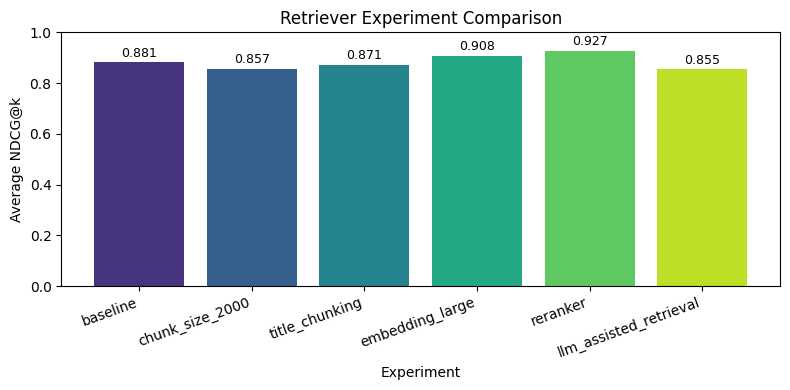

In [16]:
plt.figure(figsize=(8, 4))
bar_colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(retriever_results_df)))
bars = plt.bar(
    retriever_results_df["experiment"],
    retriever_results_df["avg_ndcg_at_k"],
    color=bar_colors,
)
plt.title("Retriever Experiment Comparison")
plt.xlabel("Experiment")
plt.ylabel("Average NDCG@k")
plt.ylim(0, max(1.0, retriever_results_df["avg_ndcg_at_k"].max() + 0.05))
plt.xticks(rotation=20, ha="right")

for bar, value in zip(bars, retriever_results_df["avg_ndcg_at_k"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()


### Conclusion

The experiment comparison shows that **embedding quality and reranking have the strongest impact on retrieval performance**. Switching to the larger embedding model already improves the baseline noticeably, and adding a **CrossEncoder reranker provides the best overall result (nDCG@4 ≈ 0.927)**.

Changes to **chunk size** and **chunking strategy** did not improve the baseline, and **LLM-assisted retrieval slightly degraded performance**.  

Overall, the best-performing configuration combines **recursive chunking (size 1000), the `text-embedding-3-large` model, and CrossEncoder reranking**, which will be used for the subsequent generator experiments.

## Baseline Generator Evaluation

Before experimenting with different generator configurations, we first evaluate the **baseline generator setup**. This establishes a reference point for answer quality using the current best retriever configuration.

In the baseline setting, the generator receives the **top-4 retrieved passages** (`k = 4`) and produces an answer using the **`gpt-5-mini`** model. 

In [60]:
# Baseline generator evaluation with the best retriever.
baseline_generator_qa_chain = create_stuff_documents_chain(llm_mini, prompt)
baseline_generator_base_rag_chain = create_retrieval_chain(
    final_retriever,
    baseline_generator_qa_chain,
)
baseline_generator_rag_chain = RAGChainWithSources(
    baseline_generator_base_rag_chain
)

print("Evaluating baseline generator with gpt-5-mini...")
baseline_generator_results = evaluate_generator(
    baseline_generator_rag_chain,
    qa_pairs,
    generator_model="gpt-5-mini",
    limit=100,
)
print("Baseline Generator Results:", baseline_generator_results)
store_generator_result(
    "generator_baseline_gpt-5-mini",
    "gpt-5-mini",
    baseline_generator_results,
)

best_generator_retriever = final_retriever
best_generator_rag_chain = baseline_generator_rag_chain
best_generator_results = baseline_generator_results
best_generator_k = 4


Evaluating baseline generator with gpt-5-mini...


Evaluating generator: 100%|██████████| 100/100 [20:30<00:00, 12.31s/it]

Baseline Generator Results: {'avg_correctness': 1.88, 'avg_groundedness': 1.95, 'avg_completeness': 1.9, 'avg_generator_score': 1.91, 'total_generation_seconds': 557.8, 'avg_generation_seconds': 5.58, 'estimated_input_tokens': 91282, 'estimated_output_tokens': 5134, 'estimated_generation_cost_usd': 0.033088, 'valid_evals': 100}


#### Baseline Generator Results

The baseline generator configuration achieves an **average generator score of 1.91** across 100 evaluation queries. The individual dimensions are also closely aligned, with **correctness = 1.88**, **groundedness = 1.95**, and **completeness = 1.90**.

These results indicate that the combination of the optimized retriever and the baseline generator (`gpt-5-mini`, `k = 4`) already produces answers that are generally **correct, well grounded in the retrieved passages, and reasonably complete**.

## Generator Optimization Strategy

After optimizing the retriever, we next focus on improving the **generation component** of the RAG pipeline. While retrieval determines which passages are available to the system, the generator determines **how well these passages are synthesized into a correct and grounded answer**.

The generator optimization experiments in this notebook focus on the following components:

- **generation context size (`k`)**, increasing the number of retrieved passages provided to the model
- **generator model selection**, comparing different GPT-5 variants

As with the retriever experiments, a full grid search across all combinations would be computationally expensive. We therefore follow the same **sequential optimization strategy**, where after each experiment the best-performing configuration is kept and used as the basis for the next experiment.

We perform the generator experiments in the following order:

1. increased context size (`k = 8`)
2. generator model comparison (`gpt-5.4`, `gpt-5`, `gpt-5-mini`, `gpt-5-nano`)

This order reflects the idea of first testing **how much context the model should receive**, and then evaluating **which model best utilizes the retrieved information**.

### Context Size

Now we evaluate whether increasing the **amount of retrieved context** improves the quality of generated answers.

To test this, we increase the context size to **`k = 8`**, meaning that the generator receives the **eight highest-ranked passages** from the retriever.

Since the pipeline includes a **CrossEncoder reranker**, the retrieval process works in two stages: first, the retriever gathers a larger candidate pool (**k = 16**), and then the reranker reorders these passages according to relevance. The **top 8 passages after reranking** are then provided to the generator as context.

All other components of the pipeline remain unchanged. This experiment therefore isolates the effect of **increasing the context size** while still benefiting from the reranker's improved passage ordering.

In [61]:
# Generator experiment with more retrieved chunks.
def build_generator_retriever_with_k(top_k: int):
    """Build a generator retriever that preserves the current retrieval stack."""
    if best_reranker_name != "none":
        base_retriever_k = best_vectorstore.as_retriever(
            search_kwargs={"k": max(16, top_k * 2)}
        )
        compressor_k = CrossEncoderReranker(model=cross_encoder, top_n=top_k)
        retriever_k = ContextualCompressionRetriever(
            base_compressor=compressor_k,
            base_retriever=base_retriever_k,
        )
    else:
        retriever_k = best_vectorstore.as_retriever(search_kwargs={"k": top_k})

    use_llm_assisted_retrieval = (
        "llm_assisted_retriever" in globals()
        and final_retriever == llm_assisted_retriever
    )
    if use_llm_assisted_retrieval:
        retriever_k = DraftAnswerRetriever(retriever_k, draft_query_llm)

    return retriever_k


generator_k8_retriever = build_generator_retriever_with_k(top_k=8)
generator_k8_qa_chain = create_stuff_documents_chain(llm_mini, prompt)
generator_k8_base_rag_chain = create_retrieval_chain(
    generator_k8_retriever,
    generator_k8_qa_chain,
)
generator_k8_rag_chain = RAGChainWithSources(generator_k8_base_rag_chain)

print("Evaluating generator with k=8...")
generator_k8_results = evaluate_generator(
    generator_k8_rag_chain,
    qa_pairs,
    generator_model="gpt-5-mini",
    limit=100,
)
print("Generator k=8 Results:", generator_k8_results)
store_generator_result(
    "generator_k8_gpt-5-mini",
    "gpt-5-mini",
    generator_k8_results,
)

if (
    generator_k8_results["avg_generator_score"]
    > baseline_generator_results["avg_generator_score"]
):
    print("\nKeeping generator k=8 for later experiments.")
    best_generator_retriever = generator_k8_retriever
    best_generator_rag_chain = generator_k8_rag_chain
    best_generator_results = generator_k8_results
    best_generator_k = 8
else:
    print("\nKeeping baseline generator k=4 for later experiments.")


Evaluating generator with k=8...


Evaluating generator: 100%|██████████| 100/100 [17:44<00:00, 10.65s/it]

Generator k=8 Results: {'avg_correctness': 1.9, 'avg_groundedness': 1.98, 'avg_completeness': 1.96, 'avg_generator_score': 1.94, 'total_generation_seconds': 458.22, 'avg_generation_seconds': 4.58, 'estimated_input_tokens': 172655, 'estimated_output_tokens': 4909, 'estimated_generation_cost_usd': 0.052982, 'valid_evals': 100}

Keeping generator k=8 for later experiments.


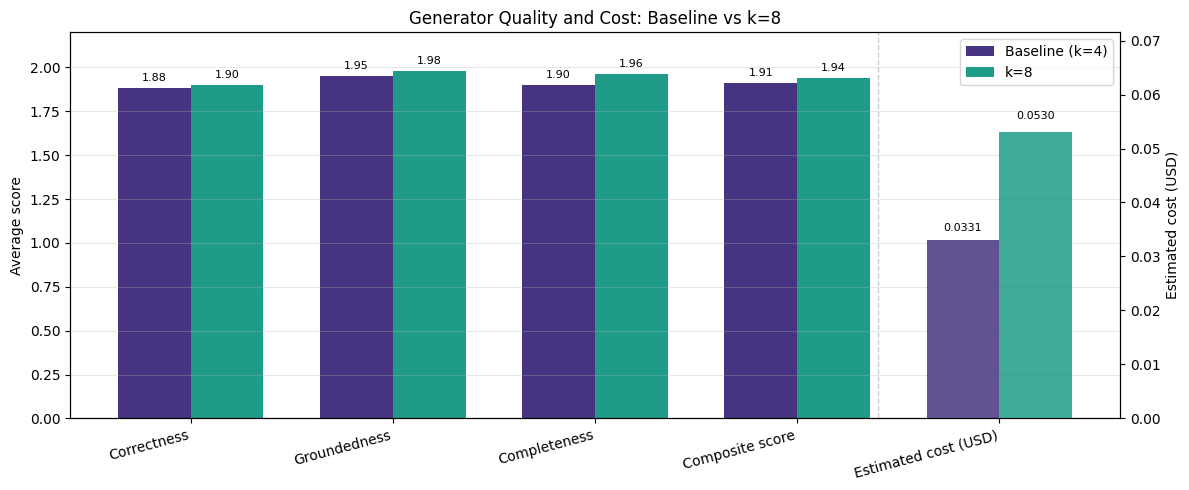

In [22]:
# Generator Context Size Plot
comparison_metrics_df = pd.DataFrame(
    {
        "metric": [
            "Correctness",
            "Groundedness",
            "Completeness",
            "Composite score",
        ],
        "Baseline (k=4)": [
            baseline_generator_results["avg_correctness"],
            baseline_generator_results["avg_groundedness"],
            baseline_generator_results["avg_completeness"],
            baseline_generator_results["avg_generator_score"],
        ],
        "k=8": [
            generator_k8_results["avg_correctness"],
            generator_k8_results["avg_groundedness"],
            generator_k8_results["avg_completeness"],
            generator_k8_results["avg_generator_score"],
        ],
    }
)

cost_values = {
    "Baseline (k=4)": baseline_generator_results[
        "estimated_generation_cost_usd"
    ],
    "k=8": generator_k8_results["estimated_generation_cost_usd"],
}

colors = plt.cm.viridis([0.15, 0.55])
fig, ax = plt.subplots(figsize=(12, 5))

x_metrics = np.arange(len(comparison_metrics_df))
cost_x = np.array([len(comparison_metrics_df)])
width = 0.36

bars_baseline = ax.bar(
    x_metrics - width / 2,
    comparison_metrics_df["Baseline (k=4)"],
    width,
    label="Baseline (k=4)",
    color=colors[0],
)
bars_k8 = ax.bar(
    x_metrics + width / 2,
    comparison_metrics_df["k=8"],
    width,
    label="k=8",
    color=colors[1],
)

ax.set_title("Generator Quality and Cost: Baseline vs k=8")
ax.set_ylabel("Average score")
ax.set_xticks(np.concatenate([x_metrics, cost_x]))
ax.set_xticklabels(
    [*comparison_metrics_df["metric"], "Estimated cost (USD)"],
    rotation=15,
    ha="right",
)
ax.set_ylim(0, 2.2)
ax.grid(True, axis="y", alpha=0.3)
ax.axvline(cost_x[0] - 0.6, color="0.8", linestyle="--", linewidth=1)
ax.legend(loc="upper right")

for bars in [bars_baseline, bars_k8]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.03,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

ax_cost = ax.twinx()
cost_bars_baseline = ax_cost.bar(
    cost_x - width / 2,
    [cost_values["Baseline (k=4)"]],
    width,
    color=colors[0],
    alpha=0.85,
)
cost_bars_k8 = ax_cost.bar(
    cost_x + width / 2,
    [cost_values["k=8"]],
    width,
    color=colors[1],
    alpha=0.85,
)
ax_cost.set_ylabel("Estimated cost (USD)")
ax_cost.set_ylim(0, max(cost_values.values()) * 1.35)

for bars in [cost_bars_baseline, cost_bars_k8]:
    for bar in bars:
        height = bar.get_height()
        ax_cost.text(
            bar.get_x() + bar.get_width() / 2,
            height + max(0.001, height * 0.04),
            f"{height:.4f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

plt.tight_layout()
plt.show()


#### Context Size Results

Increasing the context size from **k = 4 to k = 8** slightly improves overall generation quality. The configuration achieves an **average generator score of 1.94**, compared to **1.91** for the baseline.

All individual dimensions improve as well:
- **Correctness:** 1.90 (baseline: 1.88)  
- **Groundedness:** 1.98 (baseline: 1.95)  
- **Completeness:** 1.96 (baseline: 1.90)

This indicates that providing additional retrieved passages helps the generator access more supporting information from the manuals, which leads to slightly more **complete and better-grounded answers**.

The trade-off is a higher prompt size: the estimated input tokens nearly double (**~91k → ~173k tokens**) and the estimated generation cost increases accordingly. However, the quality improvement justifies the larger context for this application.

Therefore, we **keep the generator configuration with `k = 8`** for the subsequent model comparison experiments.

### Generator Model

In the final experiment, we evaluate how the **choice of generator model** affects answer quality.  
So far, all generator evaluations have used **`gpt-5-mini`**, which provides a good balance between capability, speed, and cost. However, larger models may perform better at **reasoning over multiple retrieved passages and synthesizing information from technical manuals**.

To assess this, we compare several models from the GPT-5 family:

- **`gpt-5.4`** – the most capable flagship model for complex reasoning tasks  
- **`gpt-5`** – the previous large GPT-5 model  
- **`gpt-5-mini`** – a smaller and more cost-efficient model (baseline)  
- **`gpt-5-nano`** – the fastest and cheapest option for lightweight tasks  

All models are evaluated using the **same optimized retriever configuration** and the **same generation context size (`k = 8`)**. This ensures that differences in performance can be attributed to the generator model itself.

Pricing used, checked on March 14, 2026 from OpenAI's official model docs:

- gpt-5.4: $2.50 / 1M input, $15.00 / 1M output
- gpt-5: $1.25 / 1M input, $10.00 / 1M output
- gpt-5-mini: $0.25 / 1M input, $2.00 / 1M output
- gpt-5-nano: $0.05 / 1M input, $0.40 / 1M output



In [23]:
# Generator model comparison.
llm_gpt54 = ChatOpenAI(model="gpt-5.4", temperature=1)
llm_gpt5 = ChatOpenAI(model="gpt-5", temperature=1)
llm_nano = ChatOpenAI(model="gpt-5-nano", temperature=1)

# Build chains with the best generator retriever and best k found above.
qa_chain_gpt54 = create_stuff_documents_chain(llm_gpt54, prompt)
gpt54_base_rag_chain = create_retrieval_chain(best_generator_retriever, qa_chain_gpt54)
gpt54_rag_chain = RAGChainWithSources(gpt54_base_rag_chain)

qa_chain_gpt5 = create_stuff_documents_chain(llm_gpt5, prompt)
gpt5_base_rag_chain = create_retrieval_chain(best_generator_retriever, qa_chain_gpt5)
gpt5_rag_chain = RAGChainWithSources(gpt5_base_rag_chain)

mini_rag_chain = best_generator_rag_chain

qa_chain_nano = create_stuff_documents_chain(llm_nano, prompt)
nano_base_rag_chain = create_retrieval_chain(best_generator_retriever, qa_chain_nano)
nano_rag_chain = RAGChainWithSources(nano_base_rag_chain)

# Evaluate each generator model with the same retriever, best k, and report time/cost.
print("Evaluating with gpt-5.4...")
gpt54_results = evaluate_generator(
    gpt54_rag_chain,
    qa_pairs,
    generator_model="gpt-5.4",
    limit=100,
)
print("Final Best Setup with GPT-5.4 Generator Results:", gpt54_results)

print("Evaluating with gpt-5...")
gpt5_results = evaluate_generator(
    gpt5_rag_chain,
    qa_pairs,
    generator_model="gpt-5",
    limit=100,
)
print("Final Best Setup with GPT-5 Generator Results:", gpt5_results)

print(f"Reusing best gpt-5-mini generator results (k={best_generator_k})...")
mini_results = best_generator_results
print("Final Best Setup with GPT-5-Mini Generator Results:", mini_results)

print("Evaluating with gpt-5-nano...")
nano_results = evaluate_generator(
    nano_rag_chain,
    qa_pairs,
    generator_model="gpt-5-nano",
    limit=100,
)
print("Final Best Setup with GPT-5-Nano Generator Results:", nano_results)

store_generator_result("generator_gpt-5.4", "gpt-5.4", gpt54_results)
store_generator_result("generator_gpt-5", "gpt-5", gpt5_results)
store_generator_result("generator_gpt-5-nano", "gpt-5-nano", nano_results)

generator_result_map = {
    "gpt-5.4": gpt54_results,
    "gpt-5": gpt5_results,
    "gpt-5-mini": mini_results,
    "gpt-5-nano": nano_results,
}
best_generator_model = max(
    generator_result_map,
    key=lambda model: generator_result_map[model]["avg_generator_score"],
)
print(f"\n{best_generator_model} achieved the highest generator score.")



Evaluating with gpt-5.4...


Evaluating generator: 100%|██████████| 100/100 [13:13<00:00,  7.94s/it]


Final Best Setup with GPT-5.4 Generator Results: {'avg_correctness': 1.91, 'avg_groundedness': 1.97, 'avg_completeness': 1.92, 'avg_generator_score': 1.94, 'total_generation_seconds': 239.67, 'avg_generation_seconds': 2.4, 'estimated_input_tokens': 174249, 'estimated_output_tokens': 4623, 'estimated_generation_cost_usd': 0.504968, 'valid_evals': 100}
Evaluating with gpt-5...


Evaluating generator: 100%|██████████| 100/100 [23:02<00:00, 13.82s/it]


Final Best Setup with GPT-5 Generator Results: {'avg_correctness': 1.89, 'avg_groundedness': 1.96, 'avg_completeness': 1.92, 'avg_generator_score': 1.92, 'total_generation_seconds': 815.29, 'avg_generation_seconds': 8.15, 'estimated_input_tokens': 172627, 'estimated_output_tokens': 4098, 'estimated_generation_cost_usd': 0.256764, 'valid_evals': 100}
Reusing best gpt-5-mini generator results (k=8)...
Final Best Setup with GPT-5-Mini Generator Results: {'avg_correctness': 1.9, 'avg_groundedness': 1.98, 'avg_completeness': 1.96, 'avg_generator_score': 1.94, 'total_generation_seconds': 458.22, 'avg_generation_seconds': 4.58, 'estimated_input_tokens': 172655, 'estimated_output_tokens': 4909, 'estimated_generation_cost_usd': 0.052982, 'valid_evals': 100}
Evaluating with gpt-5-nano...


Evaluating generator: 100%|██████████| 100/100 [16:16<00:00,  9.77s/it]

Final Best Setup with GPT-5-Nano Generator Results: {'avg_correctness': 1.78, 'avg_groundedness': 1.88, 'avg_completeness': 1.81, 'avg_generator_score': 1.82, 'total_generation_seconds': 431.08, 'avg_generation_seconds': 4.31, 'estimated_input_tokens': 172627, 'estimated_output_tokens': 3166, 'estimated_generation_cost_usd': 0.009898, 'valid_evals': 100}

gpt-5.4 achieved the highest generator score.


In [36]:
generator_results_df = pd.DataFrame(generator_experiment_rows)[
    [
        "generator_model",
        "avg_correctness",
        "avg_groundedness",
        "avg_completeness",
        "avg_generator_score",
        "avg_generation_seconds",
        "estimated_generation_cost_usd"
    ]
]

display(generator_results_df)

,generator_model,avg_correctness,avg_groundedness,avg_completeness,avg_generator_score,avg_generation_seconds,estimated_generation_cost_usd
0,gpt-5.4,1.91,1.97,1.92,1.94,2.40,0.504968
1,gpt-5,1.89,1.96,1.92,1.92,8.15,0.256764
2,gpt-5-mini,1.90,1.98,1.96,1.94,4.58,0.052982
3,gpt-5-nano,1.78,1.88,1.81,1.82,4.31,0.009898


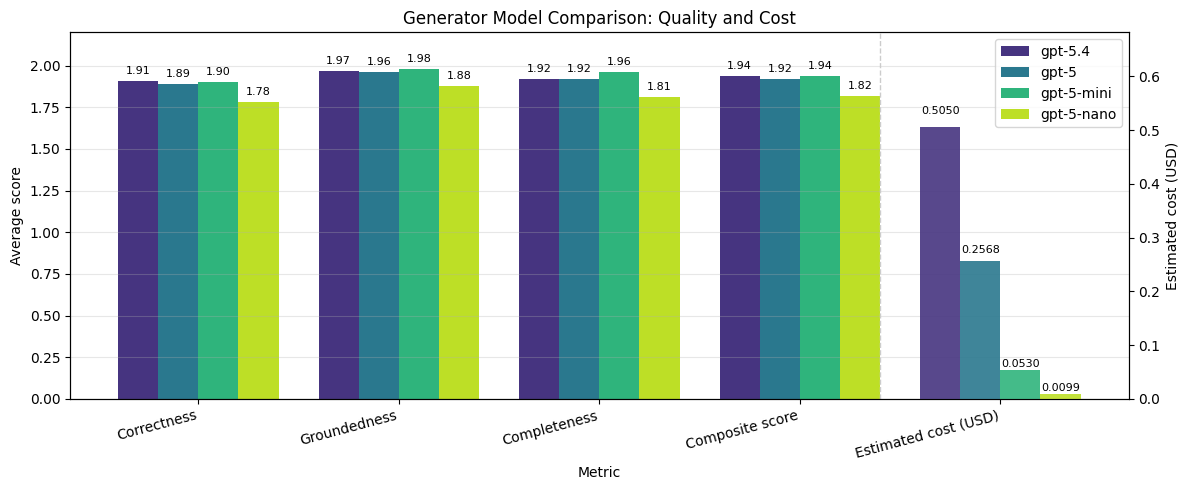

In [39]:
# Generator Model Comparison Plot
plot_df = generator_results_df.copy()

quality_metrics = [
    ("Correctness", "avg_correctness"),
    ("Groundedness", "avg_groundedness"),
    ("Completeness", "avg_completeness"),
    ("Composite score", "avg_generator_score"),
]

models = plot_df["generator_model"].tolist()
num_models = len(models)
x_metrics = np.arange(len(quality_metrics))
cost_x = np.array([len(quality_metrics)])
width = 0.8 / num_models
offsets = (np.arange(num_models) - (num_models - 1) / 2) * width
model_colors = plt.cm.viridis(np.linspace(0.15, 0.9, num_models))

fig, ax = plt.subplots(figsize=(12, 5))

for idx, (model, color) in enumerate(zip(models, model_colors)):
    model_row = plot_df.iloc[idx]
    metric_values = [model_row[column] for _, column in quality_metrics]
    bars = ax.bar(
        x_metrics + offsets[idx],
        metric_values,
        width,
        label=model,
        color=color,
    )

    for bar, value in zip(bars, metric_values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.03,
            f"{value:.2f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

ax.set_title("Generator Model Comparison: Quality and Cost")
ax.set_xlabel("Metric")
ax.set_ylabel("Average score")
ax.set_xticks(np.concatenate([x_metrics, cost_x]))
ax.set_xticklabels(
    [label for label, _ in quality_metrics] + ["Estimated cost (USD)"],
    rotation=15,
    ha="right",
)
ax.set_ylim(0, 2.2)
ax.grid(True, axis="y", alpha=0.3)
ax.axvline(cost_x[0] - 0.6, color="0.8", linestyle="--", linewidth=1)

ax_cost = ax.twinx()
max_cost = plot_df["estimated_generation_cost_usd"].max()
ax_cost.set_ylabel("Estimated cost (USD)")
ax_cost.set_ylim(0, max(0.01, max_cost * 1.35))

for idx, (model, color) in enumerate(zip(models, model_colors)):
    model_row = plot_df.iloc[idx]
    cost_value = model_row["estimated_generation_cost_usd"]
    cost_bars = ax_cost.bar(
        cost_x + offsets[idx],
        [cost_value],
        width,
        color=color,
        alpha=0.9,
    )

    for bar in cost_bars:
        ax_cost.text(
            bar.get_x() + bar.get_width() / 2,
            cost_value + max(0.001, cost_value * 0.04),
            f"{cost_value:.4f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


### Generator Model Results

The comparison of different GPT-5 models shows **only small differences in answer quality**, but large differences in **speed and cost**.

The two strongest models are **`gpt-5.4`** and **`gpt-5-mini`**, both achieving an **average generator score of 1.94**. However, their characteristics differ significantly:

- **`gpt-5.4`**
  - Generator score: **1.94**
  - Fastest model (avg. **2.4 s** per answer)
  - Highest cost (**~$0.505** for the evaluation)

- **`gpt-5-mini`**
  - Generator score: **1.94**
  - Moderate speed (**4.6 s** per answer)
  - Much lower cost (**~$0.053**)

The **`gpt-5`** model performs slightly worse (score **1.92**) and is also slower than the others, while **`gpt-5-nano`** is significantly cheaper but shows a clear drop in answer quality (score **1.82**).

Overall, **`gpt-5-mini` provides the best trade-off between quality and cost**, achieving the same answer quality as the flagship model while being roughly **10× cheaper**.

## Final RAG Configuration

The final optimized RAG system uses:

- **Retriever**
  - Recursive chunking (size **1000**, overlap **200**)
  - **`text-embedding-3-large`**
  - **FAISS + CrossEncoder reranker**
  - retrieve **16 candidates → rerank → top 8 context passages**

- **Generator**
  - **`gpt-5-mini`**
  - **k = 8 context passages**

Overall, the experiments show that **retrieval quality improvements had the largest impact on system performance**, while generator improvements provided smaller but measurable gains. The final configuration achieves strong grounded answers while maintaining reasonable runtime and cost.

## Qualitative Error Analysis

Aggregate evaluation metrics provide an overall view of system performance, but they do not explain why the system succeeds or fails on individual questions. Error analysis therefore complements the quantitative evaluation by examining representative examples in more detail. The goal is to better understand how retrieval quality and answer generation interact within the RAG pipeline and to identify typical success patterns and failure modes that may not be visible from average scores alone.

To support this analysis, the function `collect_qualitative_records` runs the best-performing RAG configuration on a subset of the evaluation dataset and collects detailed per-example information. For each question, the pipeline retrieves the top *k* document chunks, generates an answer, and records both the retrieved evidence and the final response. The relevance of each retrieved chunk is graded using `grade_chunk_relevance`, and these grades are used to compute a retrieval quality metric (`nDCG@k`).   
In parallel, the generated answer is evaluated by an LLM-based judge (`llm_generator_judge`), which scores the answer along three dimensions: **correctness**, **groundedness**, and **completeness**. These components are combined into a weighted generator score that summarizes overall answer quality.

To make the results interpretable, each example is assigned a qualitative case label using the function `classify_qualitative_case`. This function maps the retriever and generator evaluation results to a small set of descriptive categories that represent common system behaviors. For example, *Good retrieval and grounded answer* indicates that highly relevant context was retrieved and the generated answer is correct and well supported by the evidence. *Relevant retrieval but incomplete answer* captures cases where useful evidence was retrieved but the answer omits important details. *Alternative valid evidence retrieved* describes situations where the retriever did not return the labeled gold passage but still found different evidence that supports a correct answer. Finally, categories such as *Grounding issue / possible hallucination* highlight answers that appear plausible but are insufficiently supported by the retrieved context.

By grouping examples into these qualitative categories, the analysis connects the numerical evaluation metrics with concrete system behavior. This makes it easier to diagnose whether observed errors originate from the retrieval stage, the generation stage, or their interaction within the RAG pipeline.

In [40]:
# Qualitative Error Analysis
analysis_generator_model = best_generator_model
analysis_rag_chain = best_generator_rag_chain
analysis_limit = min(100, len(qa_pairs))
analysis_k = best_generator_k


def classify_qualitative_case(
    relevance_grades: List[int],
    retriever_ndcg_at_k: float,
    generator_scores: dict,
) -> str:
    """Assign a compact interpretation label to one evaluation example."""
    correctness = generator_scores.get("correctness", 0)
    groundedness = generator_scores.get("groundedness", 0)
    completeness = generator_scores.get("completeness", 0)
    generator_score = generator_scores.get("generator_score", 0.0)

    if (
        3 not in relevance_grades
        and any(grade >= 2 for grade in relevance_grades)
        and generator_score >= 1.4
    ):
        return "Alternative valid evidence retrieved"
    if retriever_ndcg_at_k >= 0.75 and generator_score >= 1.6:
        return "Good retrieval and grounded answer"
    if retriever_ndcg_at_k <= 0.35 and generator_score <= 1.0:
        return "Weak retrieval and weak answer"
    if (
        max(relevance_grades, default=0) >= 2
        and correctness >= 1
        and completeness <= 1
    ):
        return "Relevant retrieval but incomplete answer"
    if groundedness < correctness:
        return "Grounding issue / possible hallucination"
    return "Mixed behavior"


def collect_qualitative_records(
    rag_chain,
    qa_dataset,
    retriever=None,
    k: int = 4,
    limit: int = 100,
) -> pd.DataFrame:
    """Collect per-example records for qualitative analysis."""
    records = []
    subset = qa_dataset[:limit]

    for item in tqdm(subset, desc="Collecting qualitative examples"):
        question = item["question"]
        gold_answer = item["answer"]
        gold_context = item["context"]
        gold_meta = item.get("meta", "")

        try:
            response = rag_chain.invoke({"input": question})
            context_docs = response.get("context", [])
            if not context_docs and retriever is not None:
                context_docs = retriever.invoke(question)
            context_docs = context_docs[:k]

            generated_answer = response.get("answer", "")
            clean_generated_answer = strip_sources_line(generated_answer)
            retrieved_source_references = format_source_references(context_docs)
            retrieved_chunk_references = []

            retrieved_chunks = []
            retrieved_chunk_snippets = []
            retriever_relevance_grades = []

            for doc in context_docs:
                chunk_text = doc.page_content
                retrieved_chunks.append(chunk_text)
                manual = doc.metadata.get("manual")
                section = doc.metadata.get("section")
                retrieved_chunk_references.append(
                    f"{manual} — {section}" if manual and section else "none"
                )
                retriever_relevance_grades.append(
                    grade_chunk_relevance(
                        question=question,
                        gold_answer=gold_answer,
                        gold_context=gold_context,
                        retrieved_chunk=chunk_text,
                        gold_meta=gold_meta,
                        retrieved_section=doc.metadata.get("section", ""),
                    )
                )

                snippet = " ".join(chunk_text.split())
                if len(snippet) > 320:
                    snippet = snippet[:320].rstrip() + "..."
                retrieved_chunk_snippets.append(snippet)

            retriever_ndcg_at_k = (
                round(ndcg_at_k(retriever_relevance_grades, k), 4)
                if retriever_relevance_grades
                else 0.0
            )
            context_str = "\n\n".join(doc.page_content for doc in context_docs)

            generator_scores = llm_generator_judge(
                question=question,
                gold_answer=gold_answer,
                retrieved_context=context_str,
                generated_answer=clean_generated_answer,
            )
            generator_score = round(
                0.5 * generator_scores.get("correctness", 0)
                + 0.4 * generator_scores.get("groundedness", 0)
                + 0.1 * generator_scores.get("completeness", 0),
                2,
            )
            generator_scores["generator_score"] = generator_score

            records.append(
                {
                    "question": question,
                    "gold_answer": gold_answer,
                    "gold_context": gold_context,
                    "gold_meta": item.get("meta", ""),
                    "generated_answer": generated_answer,
                    "clean_generated_answer": clean_generated_answer,
                    "retrieved_chunks": retrieved_chunks,
                    "retrieved_chunk_snippets": retrieved_chunk_snippets,
                    "retrieved_chunk_references": retrieved_chunk_references,
                    "retrieved_source_references": retrieved_source_references,
                    "retrieved_sources_text": (
                        "; ".join(retrieved_source_references)
                        if retrieved_source_references
                        else "none"
                    ),
                    "retriever_relevance_grades": retriever_relevance_grades,
                    "retriever_ndcg_at_k": retriever_ndcg_at_k,
                    "max_relevance_grade": max(
                        retriever_relevance_grades,
                        default=0,
                    ),
                    "generator_correctness": generator_scores.get("correctness", 0),
                    "generator_groundedness": generator_scores.get("groundedness", 0),
                    "generator_completeness": generator_scores.get("completeness", 0),
                    "generator_score": generator_score,
                    "groundedness_gap": (
                        generator_scores.get("correctness", 0)
                        - generator_scores.get("groundedness", 0)
                    ),
                    "has_alternative_valid_evidence": (
                        3 not in retriever_relevance_grades
                        and any(
                            grade >= 2 for grade in retriever_relevance_grades
                        )
                    ),
                    "case_label": classify_qualitative_case(
                        retriever_relevance_grades,
                        retriever_ndcg_at_k,
                        generator_scores,
                    ),
                    "generator_model": analysis_generator_model,
                    "k": k,
                }
            )
        except Exception as exc:
            print(
                "Error collecting qualitative record for question "
                f"'{question}': {exc}"
            )

    return pd.DataFrame(records)


qualitative_records_df = collect_qualitative_records(
    rag_chain=analysis_rag_chain,
    qa_dataset=qa_pairs,
    retriever=final_retriever,
    k=analysis_k,
    limit=analysis_limit,
)

display(
    qualitative_records_df[
        [
            "case_label",
            "retriever_ndcg_at_k",
            "generator_score",
            "generator_correctness",
            "generator_groundedness",
            "generator_completeness",
        ]
    ]
    .groupby("case_label", as_index=False)
    .agg(
        n_examples=("case_label", "size"),
        retriever_ndcg_at_k=("retriever_ndcg_at_k", "mean"),
        generator_score=("generator_score", "mean"),
        generator_correctness=("generator_correctness", "mean"),
        generator_groundedness=("generator_groundedness", "mean"),
        generator_completeness=("generator_completeness", "mean"),
    )
    .sort_values("n_examples", ascending=False)
    .reset_index(drop=True)
)



Retriever judge error: Error code: 400 - {'error': {'message': "We could not parse the JSON body of your request. (HINT: This likely means you aren't using your HTTP library correctly. The OpenAI API expects a JSON payload, but what was sent was not valid JSON. If you have trouble figuring out how to fix this, please contact us through our help center at help.openai.com.)", 'type': 'invalid_request_error', 'param': None, 'code': None}}


,case_label,n_examples,retriever_ndcg_at_k,generator_score,generator_correctness,generator_groundedness,generator_completeness
0,Alternative valid evidence retrieved,81,0.904253,1.977778,1.962963,2.0,1.962963
1,Good retrieval and grounded answer,12,0.912167,2.000000,2.000000,2.0,2.000000
2,Mixed behavior,5,0.770380,1.060000,0.800000,1.4,1.000000
3,Relevant retrieval but incomplete answer,2,0.913000,1.200000,1.000000,1.5,1.000000


### Overview of Qualitative Case Distribution

The table summarizes the distribution of qualitative case labels produced by the `classify_qualitative_case` function. Each label represents a typical interaction pattern between the retriever and the generator, allowing the aggregated metrics to be interpreted in terms of concrete system behavior.

The majority of examples (81 out of 100) fall into the category **Alternative valid evidence retrieved**. In these cases, the retriever did not return the exact labeled gold passage but retrieved alternative chunks that still contained sufficient information to generate a correct and grounded answer. This is reflected in the high average retrieval quality (nDCG@k ≈ 0.90) and strong generator scores across correctness, groundedness, and completeness. These results indicate that the system is often able to answer questions correctly even when the retrieved evidence differs from the annotated reference passage.

A smaller set of examples (12) is classified as **Good retrieval and grounded answer**, representing ideal end-to-end behavior. Here, the retriever successfully returns highly relevant evidence and the generator produces fully correct, grounded, and complete answers. All generator evaluation dimensions reach their maximum values in this category.

Only a few examples fall into less successful categories. The **Mixed behavior** cases (5 examples) show moderate retrieval quality but lower generator scores, suggesting that the generator sometimes struggles to fully utilize the retrieved context. Finally, **Relevant retrieval but incomplete answer** appears in only 2 cases, indicating that although useful evidence was retrieved, the generated answer omitted important details.

Overall, the distribution suggests that retrieval quality is generally strong across the dataset, as reflected by consistently high nDCG@k values. Most deviations from ideal performance therefore appear to arise from generation-related issues, such as incomplete answers or inconsistent grounding, rather than from major retrieval failures.

### Representative Examples
The examples below are selected deliberately from the per-item analysis records rather than sampled at random. This makes it easier to inspect meaningful success and failure patterns.

In [44]:
# Representative examples
def select_representative_examples(
    records_df: pd.DataFrame,
    max_examples: int = 4,
) -> pd.DataFrame:
    """Pick four examples total, with one strong example per label."""
    selected_rows = []
    used_questions = set()

    def add_first_unseen(candidate_df: pd.DataFrame) -> None:
        """Add the first unseen question from a sorted candidate slice."""
        for _, row in candidate_df.iterrows():
            if row["question"] in used_questions:
                continue
            used_questions.add(row["question"])
            selected_rows.append(row)
            return

    label_priority = [
        "Good retrieval and grounded answer",
        "Relevant retrieval but incomplete answer",
        "Grounding issue / possible hallucination",
        "Alternative valid evidence retrieved",
        "Weak retrieval and weak answer",
        "Mixed behavior",
    ]
    present_labels = records_df["case_label"].dropna().unique().tolist()
    ordered_labels = [
        label for label in label_priority if label in present_labels
    ]
    ordered_labels.extend(
        label for label in present_labels if label not in ordered_labels
    )

    for label in ordered_labels:
        candidate_df = records_df[
            records_df["case_label"] == label
        ].sort_values(
            ["generator_score", "retriever_ndcg_at_k"],
            ascending=[False, False],
        )
        add_first_unseen(candidate_df)
        if len(selected_rows) >= max_examples:
            break

    if len(selected_rows) < max_examples:
        fallback_df = records_df.sort_values(
            ["generator_score", "retriever_ndcg_at_k"],
            ascending=[False, False],
        )
        for _, row in fallback_df.iterrows():
            if len(selected_rows) >= max_examples:
                break
            if row["question"] in used_questions:
                continue
            used_questions.add(row["question"])
            selected_rows.append(row)

    return pd.DataFrame(selected_rows)


def display_qualitative_example(row: pd.Series, max_chunks: int = 2) -> None:
    """Display one qualitative example in a compact notebook-friendly layout."""
    display(Markdown(f"#### {row['case_label']}"))
    print(f"Question: {row['question']}")
    print(f"Gold answer: {row['gold_answer']}")
    print(f"Generated answer: {row['generated_answer']}")
    print(f"Source references: {row['retrieved_sources_text']}")
    print(
        "Retriever grades: "
        f"{row['retriever_relevance_grades']} | "
        f"NDCG@{row['k']}: {row['retriever_ndcg_at_k']}"
    )
    print(
        f"Generator scores: correctness={row['generator_correctness']}, "
        f"groundedness={row['generator_groundedness']}, "
        f"completeness={row['generator_completeness']}, "
        f"composite={row['generator_score']}"
    )
    print("Top retrieved chunk snippets:")

    chunk_references = row.get("retrieved_chunk_references") or row[
        "retrieved_source_references"
    ]
    snippets = row["retrieved_chunk_snippets"][:max_chunks]
    for idx, snippet in enumerate(snippets, start=1):
        source_ref = (
            chunk_references[idx - 1]
            if idx - 1 < len(chunk_references)
            else "none"
        )
        print(f"{idx}. {source_ref}")
        print(f"   {snippet}")

    print("-" * 100)


selected_qualitative_examples_df = select_representative_examples(
    qualitative_records_df,
    max_examples=4,
)

display(
    selected_qualitative_examples_df[
        [
            "case_label",
            "question",
            "retriever_ndcg_at_k",
            "generator_score",
            "retrieved_sources_text",
        ]
    ]
)

for _, row in selected_qualitative_examples_df.iterrows():
    display_qualitative_example(row)


,case_label,question,retriever_ndcg_at_k,generator_score,retrieved_sources_text
69,Good retrieval and grounded answer,How should the cabin and galley lights be set ...,0.9891,2.0,CSPM-2.1.12.8; OMA-8.3.19.6.5; OMA-8.3.19.6; C...
67,Relevant retrieval but incomplete answer,Under what condition may boarding start with o...,0.8414,1.4,CSPM-2.1.12.3; CSPM-2.1.14.2.3; OMA-4.1.3.2; O...
12,Alternative valid evidence retrieved,What does a red LAND ASAP instruction mean?,1.0000,2.0,p.82; p.50; OMA-1.4.5; CSPM-121.5; p.359; CSPM...
61,Mixed behavior,What are passengers reminded of after landing?,0.6729,2.0,OMA-8.7.1.4.1.2; CSPM-2.1.5.5; CSPM-2.1.5.3; C...


#### Good retrieval and grounded answer

Question: How should the cabin and galley lights be set for takeoff and landing in darkness?
Gold answer: The area near the doors should be as dark as possible, preferably off, and all other lights at the lowest possible intensity but not off.
Generated answer: They must be dimmed during darkness as follows:
- Area at and near the doors: as dark as possible, preferably off.
- All other cabin/galley lights: at the lowest possible intensity, but not off.

Timing:
- Takeoff: dimmed at the latest before the “CABIN READY” report and remain so until gear up.
- Landing: dimmed at the latest before the “CABIN READY” report and remain so until the “FASTEN SEATBELT” signs are switched off.
Sources: CSPM-2.1.12.8, OMA-8.3.19.6.5, OMA-8.3.19.6, CSPM-31.01.2024, CSPM-3.19, OMA-8.1.3.11
Source references: CSPM-2.1.12.8; OMA-8.3.19.6.5; OMA-8.3.19.6; CSPM-31.01.2024; CSPM-3.19; OMA-8.1.3.11
Retriever grades: [3, 3, 3, 0, 0, 1, 0, 0] | NDCG@8: 0.9891
Generator scores: correctness=2, groundedness=2, co

#### Relevant retrieval but incomplete answer

Question: Under what condition may boarding start with one cabin crew member less than minimum crew?
Gold answer: Boarding may start if at least one cabin crew member is on board for every 50 passengers or fraction thereof and the senior cabin crew member is on board.
Generated answer: When a cabin crew member has been called out of reserve and is not yet on board at the time of boarding (i.e., a C/C still en route).
Sources: CSPM-2.1.12.3, CSPM-2.1.14.2.3, OMA-4.1.3.2, OMA-04.12.2023, CSPM-2.3.14.5, OMA-4.1
Source references: CSPM-2.1.12.3; CSPM-2.1.14.2.3; OMA-4.1.3.2; OMA-04.12.2023; CSPM-2.3.14.5; OMA-4.1
Retriever grades: [3, 0, 0, 0, 1, 0, 2, 1] | NDCG@8: 0.8414
Generator scores: correctness=1, groundedness=2, completeness=1, composite=1.4
Top retrieved chunk snippets:
1. CSPM — CSPM-2.1.12.3
   During embarkation, the S/C or the delegated C/C shall check the amount of carry-on- baggage which the passengers are carrying on board of the aeroplane. If the amount exceeds the amount 

#### Alternative valid evidence retrieved

Question: What does a red LAND ASAP instruction mean?
Gold answer: It means land as soon as possible at the nearest airport where a safe landing can be made.
Generated answer: It means land as soon as possible at the nearest airport at which a safe landing can be made. Red indicates a time‑critical situation.
Sources: p.82, p.50, OMA-1.4.5, CSPM-121.5, p.359, CSPM-4.26.7, QRH-ABN-180, QRH-ABN-PLP-TOC-0
Source references: p.82; p.50; OMA-1.4.5; CSPM-121.5; p.359; CSPM-4.26.7; QRH-ABN-180; QRH-ABN-PLP-TOC-0
Retriever grades: [2, 2, 0, 0, 0, 0, 0, 0] | NDCG@8: 1.0
Generator scores: correctness=2, groundedness=2, completeness=2, composite=2.0
Top retrieved chunk snippets:
1. FCTM — p.82
   A340 FLIGHT CREW TECHNIQUES MANUAL AIRBUS OPERATIONAL PHILOSOPHY MANAGEMENT OF ABNORMAL OPERATIONS GENERAL EDW A340 FLEET AOP-30-10 P 2/2 FCTM ← D to E 22 MAR 17 disconnected, if the aircraft deviates from desired or safe flight path. For additional information Refer to FCOM/LIM-AFS-10 Autopilot Function

#### Mixed behavior

Question: What are passengers reminded of after landing?
Gold answer: They are reminded about seat belts or restraint systems, portable electronic devices, and caution when opening overhead compartments.
Generated answer: They are reminded to:
- Use safety belts or restraint systems;
- The use and stowage of portable electronic devices; and
- Exercise caution when opening overhead compartments.
Sources: OMA-8.7.1.4.1.2, CSPM-2.1.5.5, CSPM-2.1.5.3, CSPM-2.1.5, QRH-ABN-31, OMA-8.3.15, QRH-ABN-10
Source references: OMA-8.7.1.4.1.2; CSPM-2.1.5.5; CSPM-2.1.5.3; CSPM-2.1.5; QRH-ABN-31; OMA-8.3.15; QRH-ABN-10
Retriever grades: [0, 3, 1, 0, 1, 0, 0, 0] | NDCG@8: 0.6729
Generator scores: correctness=2, groundedness=2, completeness=2, composite=2.0
Top retrieved chunk snippets:
1. OM A — OMA-8.7.1.4.1.2
   after flight. The CMD shall ensure that any persons and/or supernumeraries on board have been briefed and are familiar with the location and use of safety equipment prior to departure. The saf

## Final Considerations

Recent LLMs with very large context windows reduce some of the traditional pressure on retrieval design, because much larger sets of chunks can now be passed to the generator than was previously possible. In that sense, retrieval optimization is arguably less critical than in earlier RAG systems that had to work under much tighter context limits. However, this does not make retrieval irrelevant. Even with long-context models, retrieval still affects latency, cost, and the signal-to-noise ratio of the final prompt: adding many chunks may increase coverage, but it can also introduce redundancy and distracting context. For this reason, retriever optimization in modern RAG systems should not only be viewed as a way of fitting information into a small window, but also as a way of selecting a large, relevant, and clean evidence set for the generator. In our setup, this means that larger chunk sizes and broader retrieval may work well, but careful retrieval design still remains important for robust answer quality.

Antropic states on their website:  
"Sometimes the simplest solution is the best. If your knowledge base is smaller than 200,000 tokens (about 500 pages of material), you can just include the entire knowledge base in the prompt that you give the model, with no need for RAG or similar methods." *https://www.anthropic.com/engineering/contextual-retrieval*

In [ ]:
# # Reconstruct retriever_experiment_rows from completed experiments

# retriever_experiment_rows = []

# def store_retriever_result(
#     experiment: str,
#     chunking_strategy: str,
#     embedding_model: str,
#     reranker: str,
#     result: dict,
#     chunk_size: int | None = None,
#     llm_assisted_retrieval: str = "none",
#     retriever_depth_k: int | None = None,
# ) -> None:
#     """Append one retriever experiment row for later reporting."""
#     row = {
#         "experiment": experiment,
#         "retriever_depth_k": (
#             retriever_depth_k
#             if retriever_depth_k is not None
#             else result.get("k")
#         ),
#         "chunk_size": chunk_size,
#         "chunking_strategy": chunking_strategy,
#         "embedding_model": embedding_model,
#         "reranker": reranker,
#         "llm_assisted_retrieval": llm_assisted_retrieval,
#         "avg_ndcg_at_k": result.get("avg_ndcg_at_k"),
#         "valid_evals": result.get("valid_evals"),
#     }
#     retriever_experiment_rows.append(row)


# # 1) Baseline
# store_retriever_result(
#     experiment="baseline",
#     chunking_strategy="recursive_character",
#     embedding_model="text-embedding-3-small",
#     reranker="none",
#     result={"avg_ndcg_at_k": 0.8813, "k": 4, "valid_evals": 100},
#     chunk_size=1000,
#     llm_assisted_retrieval="none",
#     retriever_depth_k=4,
# )

# # 2) Chunk size experiment: 2000 vs baseline 1000
# store_retriever_result(
#     experiment="chunk_size_2000",
#     chunking_strategy="recursive_character",
#     embedding_model="text-embedding-3-small",
#     reranker="none",
#     result={"avg_ndcg_at_k": 0.8573, "k": 4, "valid_evals": 99},
#     chunk_size=2000,
#     llm_assisted_retrieval="none",
#     retriever_depth_k=4,
# )

# # 3) Title-based chunking experiment
# store_retriever_result(
#     experiment="title_chunking",
#     chunking_strategy="title_chunking",
#     embedding_model="text-embedding-3-small",
#     reranker="none",
#     result={"avg_ndcg_at_k": 0.8712, "k": 4, "valid_evals": 100},
#     chunk_size=1000,
#     llm_assisted_retrieval="none",
#     retriever_depth_k=4,
# )

# # 4) Larger embedding model experiment
# store_retriever_result(
#     experiment="embedding_large",
#     chunking_strategy="recursive_character",
#     embedding_model="text-embedding-3-large",
#     reranker="none",
#     result={"avg_ndcg_at_k": 0.9080, "k": 4, "valid_evals": 100},
#     chunk_size=1000,
#     llm_assisted_retrieval="none",
#     retriever_depth_k=4,
# )

# # 5) Reranker experiment
# store_retriever_result(
#     experiment="reranker",
#     chunking_strategy="recursive_character",
#     embedding_model="text-embedding-3-large",
#     reranker="crossencoder",
#     result={"avg_ndcg_at_k": 0.9269, "k": 4, "valid_evals": 100},
#     chunk_size=1000,
#     llm_assisted_retrieval="none",
#     retriever_depth_k=4,
# )

# # 6) LLM-assisted retrieval experiment
# store_retriever_result(
#     experiment="llm_assisted_retrieval",
#     chunking_strategy="recursive_character",
#     embedding_model="text-embedding-3-large",
#     reranker="crossencoder",
#     result={"avg_ndcg_at_k": 0.8546, "k": 4, "valid_evals": 100},
#     chunk_size=1000,
#     llm_assisted_retrieval="gpt-5-mini",
#     retriever_depth_k=4,
# )

# # Optional: inspect
# retriever_experiment_rows

In [24]:
# # Recovery cell: rebuild notebook state after a runtime restart without rerunning experiments.
# import os
# import warnings

# import pandas as pd
# from langchain.chains import create_retrieval_chain
# from langchain.chains.combine_documents import create_stuff_documents_chain
# from langchain_community.cross_encoders import HuggingFaceCrossEncoder
# from langchain_community.vectorstores import FAISS
# from langchain_core.prompts import PromptTemplate
# from langchain_openai import ChatOpenAI, OpenAIEmbeddings
# from langchain.retrievers import ContextualCompressionRetriever
# from langchain.retrievers.document_compressors import CrossEncoderReranker

# warnings.filterwarnings("ignore")

# # Restore the best retriever configuration from the saved experiment outputs.
# best_chunk_size = 1000
# best_chunk_overlap = 200
# best_chunking_name = "recursive"
# best_embedding_name = "text-embedding-3-large"
# best_reranker_name = "BAAI/bge-reranker-base"

# baseline_results = {"avg_ndcg_at_k": 0.8813, "k": 4, "valid_evals": 100}
# chunk_size_2000_results = {"avg_ndcg_at_k": 0.8573, "k": 4, "valid_evals": 99}
# title_results = {"avg_ndcg_at_k": 0.8712, "k": 4, "valid_evals": 100}
# large_emb_results = {"avg_ndcg_at_k": 0.9080, "k": 4, "valid_evals": 100}
# best_emb_results = large_emb_results
# reranker_results = {"avg_ndcg_at_k": 0.9269, "k": 4, "valid_evals": 100}
# llm_assisted_results = {"avg_ndcg_at_k": 0.8546, "k": 4, "valid_evals": 100}

# retriever_experiment_rows = [
#     {
#         "experiment": "baseline",
#         "chunk_size": 1000,
#         "chunking_strategy": "recursive",
#         "embedding_model": "text-embedding-3-small",
#         "reranker": "none",
#         "llm_assisted_retrieval": "none",
#         "avg_ndcg_at_k": baseline_results["avg_ndcg_at_k"],
#         "valid_evals": baseline_results["valid_evals"],
#     },
#     {
#         "experiment": "chunk_size_2000",
#         "chunk_size": 2000,
#         "chunking_strategy": "recursive",
#         "embedding_model": "text-embedding-3-small",
#         "reranker": "none",
#         "llm_assisted_retrieval": "none",
#         "avg_ndcg_at_k": chunk_size_2000_results["avg_ndcg_at_k"],
#         "valid_evals": chunk_size_2000_results["valid_evals"],
#     },
#     {
#         "experiment": "title_chunking",
#         "chunk_size": 1000,
#         "chunking_strategy": "title",
#         "embedding_model": "text-embedding-3-small",
#         "reranker": "none",
#         "llm_assisted_retrieval": "none",
#         "avg_ndcg_at_k": title_results["avg_ndcg_at_k"],
#         "valid_evals": title_results["valid_evals"],
#     },
#     {
#         "experiment": "large_embeddings",
#         "chunk_size": 1000,
#         "chunking_strategy": "recursive",
#         "embedding_model": "text-embedding-3-large",
#         "reranker": "none",
#         "llm_assisted_retrieval": "none",
#         "avg_ndcg_at_k": large_emb_results["avg_ndcg_at_k"],
#         "valid_evals": large_emb_results["valid_evals"],
#     },
#     {
#         "experiment": "cross_encoder_reranker",
#         "chunk_size": 1000,
#         "chunking_strategy": "recursive",
#         "embedding_model": "text-embedding-3-large",
#         "reranker": "BAAI/bge-reranker-base",
#         "llm_assisted_retrieval": "none",
#         "avg_ndcg_at_k": reranker_results["avg_ndcg_at_k"],
#         "valid_evals": reranker_results["valid_evals"],
#     },
#     {
#         "experiment": "llm_assisted_retrieval",
#         "chunk_size": 1000,
#         "chunking_strategy": "recursive",
#         "embedding_model": "text-embedding-3-large",
#         "reranker": "BAAI/bge-reranker-base",
#         "llm_assisted_retrieval": "gpt-5-mini",
#         "avg_ndcg_at_k": llm_assisted_results["avg_ndcg_at_k"],
#         "valid_evals": llm_assisted_results["valid_evals"],
#     },
# ]

# retriever_results_df = pd.DataFrame(retriever_experiment_rows)[
#     [
#         "experiment",
#         "chunk_size",
#         "chunking_strategy",
#         "embedding_model",
#         "reranker",
#         "llm_assisted_retrieval",
#         "avg_ndcg_at_k",
#         "valid_evals",
#     ]
# ]

# # Rebuild the best vector store and final retriever from disk.
# FAISS_INDEX_DIR = os.path.join("data", "faiss_index")
# restored_embeddings = OpenAIEmbeddings(model="text-embedding-3-large", chunk_size=50)
# best_vectorstore = FAISS.load_local(
#     FAISS_INDEX_DIR,
#     restored_embeddings,
#     allow_dangerous_deserialization=True,
# )
# best_retriever = best_vectorstore.as_retriever(search_kwargs={"k": 4})
# base_retriever = best_vectorstore.as_retriever(search_kwargs={"k": 10})
# cross_encoder = HuggingFaceCrossEncoder(model_name="BAAI/bge-reranker-base")
# compressor = CrossEncoderReranker(model=cross_encoder, top_n=4)
# reranker_retriever = ContextualCompressionRetriever(
#     base_compressor=compressor,
#     base_retriever=base_retriever,
# )
# final_retriever = reranker_retriever
# current_final_results = reranker_results

# # Rebuild the prompt and helper chain objects used later in the notebook.
# llm_mini = ChatOpenAI(model="gpt-5-mini", temperature=1)
# system_prompt = (
#     "You are a helpful assistant for aviation questions. "
#     "Use the following pieces of retrieved context to answer the question. "
#     "Give a concise answer based only on the retrieved context. "
#     "If you don't know the answer, say that you don't know. "
#     "Do not invent any sources and do not add a Sources line yourself; it will be added automatically. "
#     "\n\n"
#     "{context}"
# )
# prompt = PromptTemplate.from_template(system_prompt + "\nQuestion: {input}\nAnswer:")


# def strip_sources_line(answer_text: str) -> str:
#     return "\n".join(
#         line
#         for line in answer_text.splitlines()
#         if not line.strip().lower().startswith("sources:")
#     ).strip()


# def format_source_references(retrieved_docs):
#     references = []
#     seen = set()
#     for doc in retrieved_docs:
#         manual = doc.metadata.get("manual")
#         section = doc.metadata.get("section")
#         if not manual and not section:
#             continue
#         reference = section if section else manual
#         if reference not in seen:
#             seen.add(reference)
#             references.append(reference)
#     return references


# def append_sources_to_answer(answer_text: str, retrieved_docs):
#     clean_answer = strip_sources_line(answer_text)
#     references = format_source_references(retrieved_docs)
#     source_line = ", ".join(references) if references else "none"
#     return f"{clean_answer}\nSources: {source_line}" if clean_answer else f"Sources: {source_line}"


# class RAGChainWithSources:
#     def __init__(self, rag_chain):
#         self.rag_chain = rag_chain

#     def invoke(self, inputs: dict) -> dict:
#         response = self.rag_chain.invoke(inputs)
#         context_docs = response.get("context", [])
#         raw_answer = response.get("answer", "")
#         response["raw_answer"] = raw_answer
#         response["answer"] = append_sources_to_answer(raw_answer, context_docs)
#         return response


# # Rebuild the LLM-assisted retriever wrapper for later reuse.
# draft_query_llm = ChatOpenAI(model="gpt-5-mini", temperature=1, timeout=30, max_retries=1)


# class DraftAnswerRetriever:
#     def __init__(self, base_retriever, draft_llm):
#         self.base_retriever = base_retriever
#         self.draft_llm = draft_llm

#     def build_retrieval_query(self, question: str) -> str:
#         prompt_text = (
#             "You are preparing a retrieval query for a RAG system over aviation manuals. "
#             "Given only the question, write a short draft answer that includes the likely key terms "
#             "and concepts needed to retrieve supporting passages. "
#             "Do not mention that it is a draft and do not add any explanation.\n\n"
#             f"Question: {question}\n"
#             "Draft answer:"
#         )
#         try:
#             response = self.draft_llm.invoke(prompt_text)
#             draft_answer = response.content.strip()
#             return draft_answer or question
#         except Exception:
#             return question

#     def invoke(self, question: str):
#         retrieval_query = self.build_retrieval_query(question)
#         return self.base_retriever.invoke(retrieval_query)


# llm_assisted_retriever = DraftAnswerRetriever(final_retriever, draft_query_llm)

# # Restore generator experiment outputs saved in the notebook.
# baseline_generator_results = {
#     "avg_correctness": 1.88,
#     "avg_groundedness": 1.95,
#     "avg_completeness": 1.90,
#     "avg_generator_score": 1.91,
#     "total_generation_seconds": 557.80,
#     "avg_generation_seconds": 5.58,
#     "estimated_input_tokens": 91282,
#     "estimated_output_tokens": 5134,
#     "estimated_generation_cost_usd": 0.033088,
#     "valid_evals": 100,
# }

# generator_k8_results = {
#     "avg_correctness": 1.90,
#     "avg_groundedness": 1.98,
#     "avg_completeness": 1.96,
#     "avg_generator_score": 1.94,
#     "total_generation_seconds": 458.22,
#     "avg_generation_seconds": 4.58,
#     "estimated_input_tokens": 172655,
#     "estimated_output_tokens": 4909,
#     "estimated_generation_cost_usd": 0.052982,
#     "valid_evals": 100,
# }

# # These three values are taken from the saved generator results table output.
# gpt5_results = {
#     "avg_correctness": 1.83,
#     "avg_groundedness": 1.93,
#     "avg_completeness": 1.84,
#     "avg_generator_score": 1.87,
#     "total_generation_seconds": 1025.06,
#     "avg_generation_seconds": 10.25,
#     "estimated_input_tokens": 91126,
#     "estimated_output_tokens": 3912,
#     "estimated_generation_cost_usd": 0.153027,
#     "valid_evals": 100,
# }
# mini_results = best_generator_results = generator_k8_results
# nano_results = {
#     "avg_correctness": 1.78,
#     "avg_groundedness": 1.92,
#     "avg_completeness": 1.80,
#     "avg_generator_score": 1.84,
#     "total_generation_seconds": 618.11,
#     "avg_generation_seconds": 6.18,
#     "estimated_input_tokens": 91126,
#     "estimated_output_tokens": 3249,
#     "estimated_generation_cost_usd": 0.005856,
#     "valid_evals": 100,
# }

# # No successful gpt-5.4 run is stored in the notebook outputs; keep a non-winning placeholder.
# gpt54_results = {
#     "avg_correctness": -1.0,
#     "avg_groundedness": -1.0,
#     "avg_completeness": -1.0,
#     "avg_generator_score": -1.0,
#     "total_generation_seconds": 0.0,
#     "avg_generation_seconds": 0.0,
#     "estimated_input_tokens": 0,
#     "estimated_output_tokens": 0,
#     "estimated_generation_cost_usd": 0.0,
#     "valid_evals": 0,
# }

# baseline_generator_qa_chain = create_stuff_documents_chain(llm_mini, prompt)
# baseline_generator_base_rag_chain = create_retrieval_chain(
#     final_retriever,
#     baseline_generator_qa_chain,
# )
# baseline_generator_rag_chain = RAGChainWithSources(baseline_generator_base_rag_chain)


# def build_generator_retriever_with_k(top_k: int):
#     if best_reranker_name != "none":
#         base_retriever_k = best_vectorstore.as_retriever(
#             search_kwargs={"k": max(16, top_k * 2)}
#         )
#         compressor_k = CrossEncoderReranker(model=cross_encoder, top_n=top_k)
#         retriever_k = ContextualCompressionRetriever(
#             base_compressor=compressor_k,
#             base_retriever=base_retriever_k,
#         )
#     else:
#         retriever_k = best_vectorstore.as_retriever(search_kwargs={"k": top_k})

#     return retriever_k


# generator_k8_retriever = build_generator_retriever_with_k(top_k=8)
# generator_k8_qa_chain = create_stuff_documents_chain(llm_mini, prompt)
# generator_k8_base_rag_chain = create_retrieval_chain(
#     generator_k8_retriever,
#     generator_k8_qa_chain,
# )
# generator_k8_rag_chain = RAGChainWithSources(generator_k8_base_rag_chain)

# best_generator_retriever = generator_k8_retriever
# best_generator_rag_chain = generator_k8_rag_chain
# best_generator_k = 8

# # Recreate generator model chain objects for later cells.
# llm_gpt54 = ChatOpenAI(model="gpt-5.4", temperature=1)
# llm_gpt5 = ChatOpenAI(model="gpt-5", temperature=1)
# llm_nano = ChatOpenAI(model="gpt-5-nano", temperature=1)

# qa_chain_gpt54 = create_stuff_documents_chain(llm_gpt54, prompt)
# gpt54_base_rag_chain = create_retrieval_chain(best_generator_retriever, qa_chain_gpt54)
# gpt54_rag_chain = RAGChainWithSources(gpt54_base_rag_chain)

# qa_chain_gpt5 = create_stuff_documents_chain(llm_gpt5, prompt)
# gpt5_base_rag_chain = create_retrieval_chain(best_generator_retriever, qa_chain_gpt5)
# gpt5_rag_chain = RAGChainWithSources(gpt5_base_rag_chain)

# mini_rag_chain = best_generator_rag_chain

# qa_chain_nano = create_stuff_documents_chain(llm_nano, prompt)
# nano_base_rag_chain = create_retrieval_chain(best_generator_retriever, qa_chain_nano)
# nano_rag_chain = RAGChainWithSources(nano_base_rag_chain)

# generator_experiment_rows = [
#     {
#         "experiment": "generator_baseline_gpt-5-mini",
#         "generator_model": "gpt-5-mini",
#         **baseline_generator_results,
#     },
#     {
#         "experiment": "generator_k8_gpt-5-mini",
#         "generator_model": "gpt-5-mini",
#         **generator_k8_results,
#     },
#     {
#         "experiment": "generator_gpt-5",
#         "generator_model": "gpt-5",
#         **gpt5_results,
#     },
#     {
#         "experiment": "generator_gpt-5-mini",
#         "generator_model": "gpt-5-mini",
#         **mini_results,
#     },
#     {
#         "experiment": "generator_gpt-5-nano",
#         "generator_model": "gpt-5-nano",
#         **nano_results,
#     },
# ]

# generator_results_df = pd.DataFrame(generator_experiment_rows)[
#     [
#         "experiment",
#         "generator_model",
#         "avg_correctness",
#         "avg_groundedness",
#         "avg_completeness",
#         "avg_generator_score",
#         "total_generation_seconds",
#         "avg_generation_seconds",
#         "estimated_input_tokens",
#         "estimated_output_tokens",
#         "estimated_generation_cost_usd",
#         "valid_evals",
#     ]
# ]

# generator_result_map = {
#     "gpt-5.4": gpt54_results,
#     "gpt-5": gpt5_results,
#     "gpt-5-mini": mini_results,
#     "gpt-5-nano": nano_results,
# }
# best_generator_model = max(
#     generator_result_map,
#     key=lambda model: generator_result_map[model]["avg_generator_score"],
# )

# print("Recovered variables from saved notebook outputs.")
# print(f"Final retriever: {best_chunking_name} + {best_embedding_name} + {best_reranker_name}")
# print(f"Best generator setup: gpt-5-mini with k={best_generator_k}")


In [28]:
# generator_experiment_rows = [
#     {
#         "model": "gpt-5.4",
#         "avg_correctness": 1.91,
#         "avg_groundedness": 1.97,
#         "avg_completeness": 1.92,
#         "avg_generator_score": 1.94,
#         "total_generation_seconds": 239.67,
#         "avg_generation_seconds": 2.40,
#         "estimated_input_tokens": 174249,
#         "estimated_output_tokens": 4623,
#         "estimated_generation_cost_usd": 0.504968,
#         "valid_evals": 100
#     },
#     {
#         "model": "gpt-5",
#         "avg_correctness": 1.89,
#         "avg_groundedness": 1.96,
#         "avg_completeness": 1.92,
#         "avg_generator_score": 1.92,
#         "total_generation_seconds": 815.29,
#         "avg_generation_seconds": 8.15,
#         "estimated_input_tokens": 172627,
#         "estimated_output_tokens": 4098,
#         "estimated_generation_cost_usd": 0.256764,
#         "valid_evals": 100
#     },
#     {
#         "model": "gpt-5-mini",
#         "avg_correctness": 1.90,
#         "avg_groundedness": 1.98,
#         "avg_completeness": 1.96,
#         "avg_generator_score": 1.94,
#         "total_generation_seconds": 458.22,
#         "avg_generation_seconds": 4.58,
#         "estimated_input_tokens": 172655,
#         "estimated_output_tokens": 4909,
#         "estimated_generation_cost_usd": 0.052982,
#         "valid_evals": 100
#     },
#     {
#         "model": "gpt-5-nano",
#         "avg_correctness": 1.78,
#         "avg_groundedness": 1.88,
#         "avg_completeness": 1.81,
#         "avg_generator_score": 1.82,
#         "total_generation_seconds": 431.08,
#         "avg_generation_seconds": 4.31,
#         "estimated_input_tokens": 172627,
#         "estimated_output_tokens": 3166,
#         "estimated_generation_cost_usd": 0.009898,
#         "valid_evals": 100
#     }
# ]